In [1]:

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from chemlib import Compound
from scipy import constants
from scipy.interpolate import LinearNDInterpolator, CloughTocher2DInterpolator, RBFInterpolator, NearestNDInterpolator,interp1d,UnivariateSpline
from mpl_toolkits.mplot3d import Axes3D
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from scipy import stats
from sklearn.neighbors import LocalOutlierFactor
from scipy.optimize import fsolve, least_squares
import os

In [2]:
# база данных по молярным массам 
M_Fe = Compound("Fe").molar_mass()
M_S = Compound("S").molar_mass()
M_As = Compound("As").molar_mass()
M_K = Compound("K").molar_mass()
M_NH4 = Compound("NH4").molar_mass()
M_H3O = 19.02 
M_FeS2 = Compound("FeS2").molar_mass()
M_FeAsS = Compound("FeAsS").molar_mass()
M_MgOH2 = Compound("Mg(OH)2").molar_mass()
M_H2SO4 = Compound("H2SO4").molar_mass()
M_MgSO4 = Compound("MgSO4").molar_mass()

# ТЕРМОДИНАМИЧЕСКИЕ ПАРАМЕТРЫ ДЛЯ РАЗНЫХ ЯРОЗИТОВ
jarosite_params = {
   'K': {
        'name': 'K-ярозит',
        'dH0': 49683.33,  # Дж/моль
        'dS0': 233.52,    # Дж/(моль·К)
        'M_cation': M_K,
        'ion_name': 'K',
        'charge': 1,
        'color': 'blue'
    },
    'H3O': {
        'name': 'H₃O-ярозит',
        'dH0': 90630,  # Дж/моль
        'dS0': 248.2166667,   # Дж/(моль·К)
        'M_cation': M_H3O,
        'ion_name': 'H3O', 
        'charge': 1,
        'color': 'red'
    },
    'NH4': {
        'name': 'NH₄-ярозит',
        'dH0': 58920,  # Дж/моль
        'dS0': 236.4866667,    # Дж/(моль·К)
        'M_cation': M_NH4,
        'ion_name': 'NH4',
        'charge': 1,
        'color': 'purple'
        }
  }  

# массовые проценты компонентов
Fe_w = 20.4    
S_w = 21.2     
As_w = 6.8     
K_w = 0.1     
NH4_w = 0.2  

# дано параметры пульпы
Ж_Т = 2
mass_ore = 26.6 * 10 ** 6  # г
Mg_S = 0.6 # 60% от массы серы
Fe_Ox = 0.9 #10% железа недоокисляется

# Диапазоны параметров
S_Ox_range = np.linspace(0.2, 1.0, 10)  # от 20% до 100% 
temps_range = np.linspace(293, 513.15, 10)  # от 25°C до 240°C 

mass_liquid = Ж_Т * mass_ore / 1000 * (Ж_Т + 1)  # кг
mass_solid = mass_ore / (Ж_Т + 1)  # г

# Параметры добавки H2SO4
H2SO4_add_percent = 0.2  # 20% от массы воды
m_H2SO4_add = H2SO4_add_percent * mass_liquid  # кг

# массы компонентов, г
m_Fe = Fe_w * mass_solid / 100   
m_S = S_w * mass_solid / 100      
m_As = As_w * mass_solid / 100
m_K = K_w * mass_solid / 100
m_NH4 = NH4_w * mass_solid / 100

# Параметры добавки Mg(OH)2
m_MgOH_add = Mg_S * m_S  # г

# количество арсенопирита по мышьяку
n_FeAsS = m_As / M_As
m_Fe_FeAsS = n_FeAsS * M_Fe
m_S_FeAsS = n_FeAsS * M_S
m_FeAsS = n_FeAsS * M_FeAsS

# оставшиеся массы
m_Fe_left = m_Fe - m_Fe_FeAsS
m_S_left = m_S - m_S_FeAsS

# Проверяем стехиометрию пирита
n_FeS2_from_Fe = m_Fe_left / M_Fe
n_FeS2_from_S = m_S_left / (2 * M_S) 

# Берем ограничивающий реагент
n_FeS2 = min(n_FeS2_from_Fe, n_FeS2_from_S)
m_FeS2 = n_FeS2 * M_FeS2

# Избыточный компонент из других минералов
n_S_from_nowhere = 0
n_Fe_from_nowhere = 0

if n_FeS2_from_Fe < n_FeS2_from_S:
    n_S_from_nowhere = (m_S_left / M_S) - (2 * n_FeS2)
else:
    n_Fe_from_nowhere = m_Fe_left / M_Fe  - n_FeS2

pd.DataFrame({
    'Вещество': ['Fe', 'S', 'As', 'K', 'NH4', 'H3O', 'FeS2', 'FeAsS', 'Mg(OH)2', 'H2SO4', 'MgSO4'],
    'Молярная масса, г/моль': [M_Fe, M_S, M_As, M_K, M_NH4, M_H3O, M_FeS2, M_FeAsS, M_MgOH2, M_H2SO4, M_MgSO4],  
    'Масса, кг': [m_Fe/ 1000, m_S / 1000, m_As / 1000, m_K / 1000, m_NH4 / 1000, 0, m_FeS2 / 1000, m_FeAsS / 1000, m_MgOH_add/ 1000, m_H2SO4_add/ 1000, 0],
    'Количество, моль': [m_Fe/ M_Fe, m_S / M_S, m_As / M_As, m_K / M_K, m_NH4 / M_NH4, 0, m_FeS2 / M_FeS2, m_FeAsS / M_FeAsS, m_MgOH_add/ M_MgOH2, m_H2SO4_add/ M_H2SO4, 0],
})


,Вещество,"Молярная масса, г/моль","Масса, кг","Количество, моль"
0,Fe,55.845,1808.800000,32389.649924
1,S,32.065,1879.733333,58622.589532
2,As,74.922,602.933333,8047.480491
3,K,39.098,8.866667,226.780568
4,NH4,18.039,17.733333,983.055232
5,H3O,19.020,0.000000,0.000000
6,FeS2,119.975,2920.451778,24342.169433
7,FeAsS,162.832,1310.387343,8047.480491
8,Mg(OH)2,58.319,1127.840000,19339.151906
9,H2SO4,98.077,31.920000,325.458568


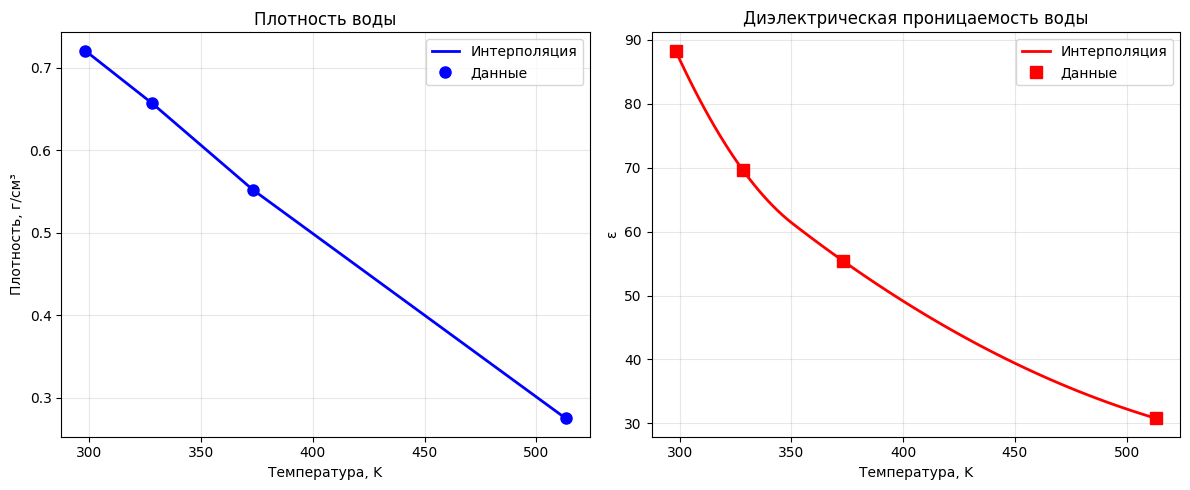

In [3]:

# Данные из таблицы для воды (давление 10 МПа = 100 атм)
table_temps_K = np.array([298.15, 328.15, 373.15, 513.15])
table_epsilon = np.array([88.3, 69.67, 55.4, 30.79])
table_density_g_per_cm3 = np.array([0.72068, 0.65672, 0.55203, 0.27483])

# Создаем интерполяционные функции
epsilon_interp = interp1d(table_temps_K, table_epsilon, kind='quadratic', 
                          fill_value='extrapolate')
density_interp = interp1d(table_temps_K, table_density_g_per_cm3, kind='slinear',
                          fill_value='extrapolate')

def water_density(T_K):
    density_g_per_cm3 = float(density_interp(T_K))
    return density_g_per_cm3

def water_dielectric(T_K):
    return float(epsilon_interp(T_K))

# Создаем диапазон температур для построения графика
T_range = np.linspace(min(table_temps_K), max(table_temps_K), 100)

# Вычисляем значения плотности и диэлектрической проницаемости
density_values = [water_density(T) for T in T_range]
epsilon_values = [water_dielectric(T) for T in T_range]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# График плотности
axes[0].plot(T_range, density_values, 'b-', linewidth=2)
axes[0].plot(table_temps_K, table_density_g_per_cm3, 'bo', markersize=8)
axes[0].set_title('Плотность воды')
axes[0].set_xlabel('Температура, K')
axes[0].set_ylabel('Плотность, г/см³')
axes[0].grid(True, alpha=0.3)
axes[0].legend(['Интерполяция', 'Данные'])

# График диэлектрической проницаемости
axes[1].plot(T_range, epsilon_values, 'r-', linewidth=2)
axes[1].plot(table_temps_K, table_epsilon, 'rs', markersize=8)
axes[1].set_title('Диэлектрическая проницаемость воды')
axes[1].set_xlabel('Температура, K')
axes[1].set_ylabel('ε')
axes[1].grid(True, alpha=0.3)
axes[1].legend(['Интерполяция', 'Данные'])

plt.tight_layout()
plt.show()

Было точек: 22
После усреднения: 16
Усреднено дубликатов: 6


NameError: name 'T' is not defined

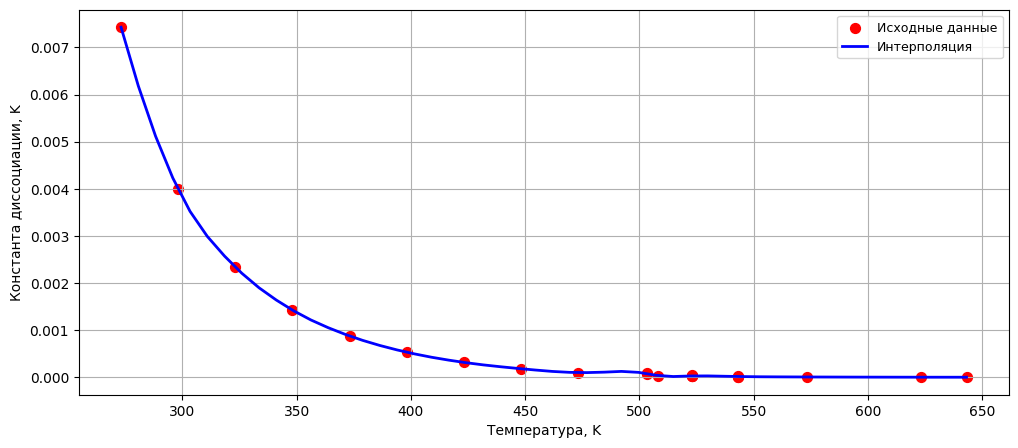

In [4]:
file_path_Fe = r'F:\Термодинамика процесса гидролиза\Mg influence\Данные.xlsx'
df = pd.read_excel(file_path_Fe, sheet_name='Equilibrium constants_MgSO4')


temp_row_MgSO4 = df.iloc[:, 0].values
logK_row_MgSO4 = df.iloc[:, 1].values

temp_MgSO4 = temp_row_MgSO4 + 273.15
K_MgSO4 = 10 ** logK_row_MgSO4

data_df = pd.DataFrame({
    'temp': temp_MgSO4,
    'K': K_MgSO4,
    'logK': logK_row_MgSO4
})

averaged_df = data_df.groupby('temp', as_index=False).mean()

temp_avg = averaged_df['temp'].values
K_avg = averaged_df['K'].values
logK_avg = averaged_df['logK'].values

print(f"Было точек: {len(temp_MgSO4)}")
print(f"После усреднения: {len(temp_avg)}")
print(f"Усреднено дубликатов: {len(temp_MgSO4) - len(temp_avg)}")

# Создание сетки для интерполяции
temp_grid_MgSO4 = np.linspace(temp_avg.min(), temp_avg.max(), 50)

# Интерполяция по усредненным данным
K_interp_MgSO4 = interp1d(temp_avg, K_avg, kind='quadratic', fill_value='extrapolate')

# Вычисление значений на сетке
K_MgSO4_interpolated = K_interp_MgSO4(temp_grid_MgSO4)

fig, ax = plt.subplots(1, 1, figsize=(12, 5))

ax.scatter(temp_MgSO4, K_MgSO4, c='red', s=50, alpha=1.0, label='Исходные данные')
ax.plot(temp_grid_MgSO4, K_MgSO4_interpolated, 'b-', linewidth=2, label='Интерполяция')
ax.set_xlabel('Температура, K', fontsize=10)
ax.set_ylabel('Константа диссоциации, K', fontsize=10)
ax.legend(fontsize=9)
ax.grid(True)

K_value = K_interp_MgSO4(T)  
print(f"K для MgSO4 при T={T}K: {K_value}") # pyright: ignore[reportUndefinedVariable]



In [ ]:


# код очистки данных
temp_row_sol_Mg_SO4 = df.iloc[:, 0].values
sol_row_sol_Mg_SO4 = df.iloc[:, 1].values
conc_row_sol_Mg_SO4 = df.iloc[:, 2].values

df['good'] = True

df['T_rounded_sol_Mg_SO4'] = np.round(df.iloc[:, 0] / 5) * 5  
df['C_rounded_sol_Mg_SO4'] = np.round(df.iloc[:, 2]) 

group_cols_sol_Mg_SO4 = ['T_rounded_sol_Mg_SO4', 'C_rounded_sol_Mg_SO4']
sol_col_sol_Mg_SO4 = df.columns[1]

for (T, C), group in df.groupby(group_cols_sol_Mg_SO4):
    if len(group) >= 2:
        mu = group[sol_col_sol_Mg_SO4].mean()
        sigma = group[sol_col_sol_Mg_SO4].std()
        if sigma > 0:
            mask = np.abs(group[sol_col_sol_Mg_SO4] - mu) <= 3 * sigma
            df.loc[group.index, 'good'] = mask


df_clean = df[df['good']].copy()

temp_clean_sol_Mg_SO4 = df_clean.iloc[:, 0].values
sol_clean_sol_Mg_SO4  = df_clean.iloc[:, 1].values
conc_clean_sol_Mg_SO4 = df_clean.iloc[:, 2].values

X = np.column_stack([temp_clean_sol_Mg_SO4, conc_clean_sol_Mg_SO4])
y = sol_clean_sol_Mg_SO4

z_thresh = 3
k = 15

nbrs = NearestNeighbors(n_neighbors=k + 1)
nbrs.fit(X)
dist, idx = nbrs.kneighbors(X)

mask_good = np.ones(len(y), dtype=bool)

for i in range(len(y)):
    neigh_idx = idx[i, 1:]  # исключаем саму точку
    local_mean = np.mean(y[neigh_idx])
    local_std  = np.std(y[neigh_idx])
    
    if local_std == 0:
        continue
    
    z = np.abs(y[i] - local_mean) / local_std
    if z > z_thresh:
        mask_good[i] = False

temp_sol_Mg_SO4 = temp_clean_sol_Mg_SO4[mask_good]
sol_sol_Mg_SO4  = sol_clean_sol_Mg_SO4[mask_good]
conc_sol_Mg_SO4 = conc_clean_sol_Mg_SO4[mask_good]

print(f"Исходных точек: {len(df)}")
print(f"После очистки дубликатов: {len(df_clean)}")
print(f"После удаления локальных выбросов: {len(temp_sol_Mg_SO4)}")

points_sol_Mg_SO4 = np.column_stack([temp_sol_Mg_SO4, conc_sol_Mg_SO4])  # X - temp, Y - conc
values_sol_Mg_SO4 = sol_sol_Mg_SO4  # Z - sol

fig = plt.figure(figsize=(16,12), dpi=100)
ax = fig.add_subplot(111, projection='3d')
plt.subplots_adjust(left=0.05, right=0.95, bottom=0.05)
ax.scatter(
    temp_sol_Mg_SO4, conc_sol_Mg_SO4, sol_sol_Mg_SO4,
    c='green', label='Оставшиеся', s=30
)

ax.scatter(
    temp_clean_sol_Mg_SO4[~mask_good], conc_clean_sol_Mg_SO4[~mask_good], sol_clean_sol_Mg_SO4[~mask_good],
    c='red', label='Выбросы', s=60, marker='x'
)
ax.grid(True, alpha=0.3)
ax.view_init(elev=20, azim=45)
ax.set_xlabel('Температура, К')
ax.set_ylabel('Концентрация серной кислоты, моль/кг')
ax.set_zlabel('Растворимость сульфата магния, моль/кг')
ax.legend(fontsize=12, loc='best')
plt.show()



NameError: name 'pd' is not defined

✓ RBF (cubic): успешно
✓ RBF (linear): успешно
✓ RBF (TPS): успешно


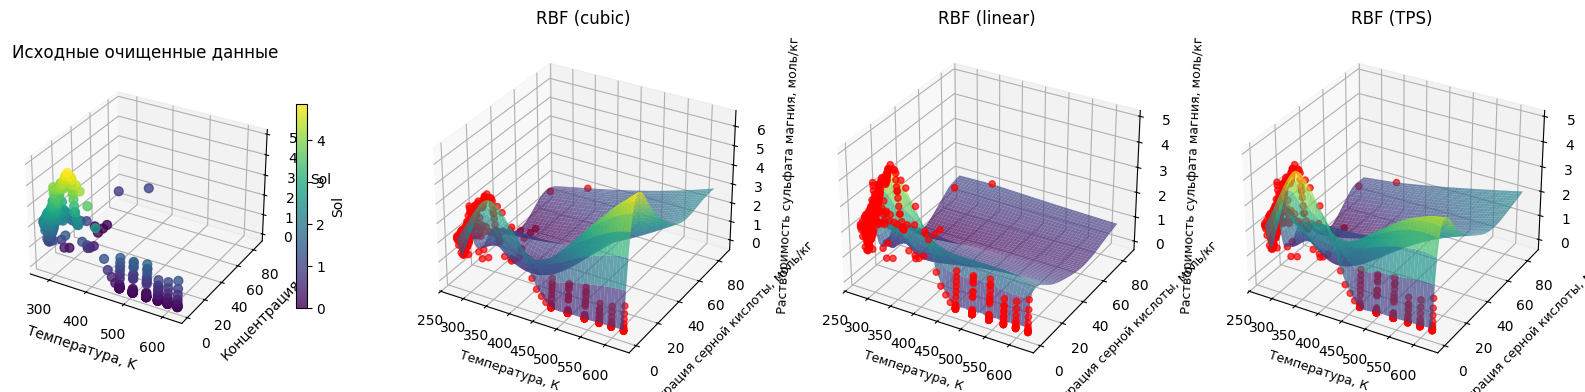

In [ ]:
scaler = StandardScaler()
points_normalized_sol_Mg_SO4 = scaler.fit_transform(points_sol_Mg_SO4)

# Создаем сетку для визуализации
temp_grid_sol_Mg_SO4 = np.linspace(temp_sol_Mg_SO4.min(), temp_sol_Mg_SO4.max(), 50)
conc_grid_sol_Mg_SO4 = np.linspace(conc_sol_Mg_SO4.min(), conc_sol_Mg_SO4.max(), 50)
temp_mesh_sol_Mg_SO4, conc_mesh_sol_Mg_SO4 = np.meshgrid(temp_grid_sol_Mg_SO4, conc_grid_sol_Mg_SO4)
grid_points_sol_Mg_SO4 = np.column_stack([temp_mesh_sol_Mg_SO4.ravel(), conc_mesh_sol_Mg_SO4.ravel()])
grid_points_normalized_sol_Mg_SO4 = scaler.transform(grid_points_sol_Mg_SO4)

# Методы интерполяции 
method_cfg = {
    'RBF (cubic)': True,
    'RBF (linear)': True,
    'RBF (quintic)': True,
    'RBF (TPS)': True,
    'Linear': False,
    'Cubic (Clough-Tocher)': False,
    'Nearest neighbor interpolation': False,
}


methods = {
    'RBF (cubic)': RBFInterpolator(points_normalized_sol_Mg_SO4, values_sol_Mg_SO4, kernel='cubic', smoothing=0.1),
    'RBF (linear)': RBFInterpolator(points_normalized_sol_Mg_SO4, values_sol_Mg_SO4, kernel='linear', smoothing=0.1),
    'RBF (TPS)': RBFInterpolator(points_normalized_sol_Mg_SO4, values_sol_Mg_SO4, kernel='thin_plate_spline', smoothing=0.1)
}

# Интерполяция и визуализация
fig = plt.figure(figsize=(20, 15))

# График исходных данных
ax0 = fig.add_subplot(3, 4, 1, projection='3d')
sc0 = ax0.scatter(temp_sol_Mg_SO4, conc_sol_Mg_SO4, sol_sol_Mg_SO4, c=sol_sol_Mg_SO4, cmap='viridis', s=40, alpha=0.8)
ax0.set_title('Исходные очищенные данные', fontsize=12, pad=10)
ax0.set_xlabel('Температура, K', fontsize=10)
ax0.set_ylabel('Концентрация', fontsize=10)
ax0.set_zlabel('Sol', fontsize=10)
fig.colorbar(sc0, ax=ax0, shrink=0.6, label='Sol')

sol_results_sol_Mg_SO4 = {}

# Интерполяция и построение графиков
for idx, (name, interp) in enumerate(methods.items(), 2):
    if interp is None:
        continue
    
    try:
        # Выполняем интерполяцию
        if name.startswith('RBF'):
            sol_interp = interp(grid_points_normalized_sol_Mg_SO4)
        else:
            sol_interp = interp(grid_points_sol_Mg_SO4)
        
        sol_grid_sol_Mg_SO4 = sol_interp.reshape(temp_mesh_sol_Mg_SO4.shape)
        sol_results_sol_Mg_SO4[name] = sol_grid_sol_Mg_SO4
        
        # Создаем подграфик
        ax = fig.add_subplot(3, 4, idx, projection='3d')
        
        # Поверхность интерполяции
        surf = ax.plot_surface(temp_mesh_sol_Mg_SO4, conc_mesh_sol_Mg_SO4, sol_grid_sol_Mg_SO4, 
                              cmap='viridis', 
                              alpha=0.7,
                              linewidth=0.2,
                              antialiased=True,
                              rstride=1, cstride=1)
        
        # Исходные точки
        ax.scatter(temp_sol_Mg_SO4, conc_sol_Mg_SO4, sol_sol_Mg_SO4, c='red', s=20, alpha=0.7, label='Данные')
        
        ax.set_title(name, fontsize=12, pad=10)
        ax.set_xlabel('Температура, К', fontsize=9)
        ax.set_ylabel('Концентрация серной кислоты, моль/кг', fontsize=9)
        ax.set_zlabel('Растворимость сульфата магния, моль/кг', fontsize=9)
        
        
        print(f"✓ {name}: успешно")
        
    except Exception as e:
        print(f"✗ {name}: ошибка - {str(e)}")
        sol_results_sol_Mg_SO4[name] = None

Сравним конкретные значения растворимости, полученные различными методами интерполяции

In [ ]:

def get_MgSO4_solubility_PBF_cub(T, H2SO4_conc):
    temp_idx = np.argmin(np.abs(temp_grid_sol_Mg_SO4 - T))
    conc_idx = np.argmin(np.abs(conc_grid_sol_Mg_SO4 - H2SO4_conc))
 
    solubility = sol_results_sol_Mg_SO4['RBF (cubic)'][conc_idx, temp_idx]
    
    return float(solubility)

def get_MgSO4_solubility_RBF_lin(T, H2SO4_conc):
    temp_idx = np.argmin(np.abs(temp_grid_sol_Mg_SO4 - T))
    conc_idx = np.argmin(np.abs(conc_grid_sol_Mg_SO4 - H2SO4_conc))
 
    solubility = sol_results_sol_Mg_SO4['RBF (linear)'][conc_idx, temp_idx]
    
    return float(solubility)

# Пример использования
T = 510 # K
conc = 0.4  # моль/кг

pd.DataFrame({
    'Кубическая RBF': [get_MgSO4_solubility_PBF_cub(T, conc)],
    'Линейная RBF': [get_MgSO4_solubility_RBF_lin(T, conc)]
})


,Кубическая RBF,Линейная RBF
0,0.002787,0.034162


In [ ]:
ion_radii_dict = {
    'H': 4.78 * 1e-8,    
    'K': 3.71 * 1e-8,    
    'Na': 4.32 * 1e-8,   
    'Fe3': 9.0 * 1e-8,  
    'Fe2': 5.08 * 1e-8,  
    'SO4': 5.31 * 1e-8,
    'HSO4': 4.5 * 1e-8,
    'NH4': 2.5 * 1e-8,  
    'Mg2': 8.0 * 1e-8,
    'MgSO4': 3.0 * 1e-8,
    'OH': 4.0 * 1e-8
}    

k_CGS = 1.38054e-16
e_CGS = 4.80320425e-10

def get_ion_radius(ion_name):
    return ion_radii_dict.get(ion_name, 4.0e-8)
    
def calculate_A(T, density, epsilon):
    numerator = (2 * np.pi * constants.N_A)**0.5 * (e_CGS**3) * (density**0.5)
    denominator = 2.302585 * 1000**0.5 * (epsilon * k_CGS * T)**1.5
    return numerator / denominator

def calculate_B(T, density, epsilon):
    numerator = 8 * np.pi * constants.N_A * density * e_CGS**2
    denominator = epsilon * k_CGS * T * 1000
    return (numerator / denominator)**0.5

def calculate_ionic_strength(concentrations, charges):
    I = 0.0
    for c, z in zip(concentrations, charges):
        I += 0.5 * c * z**2
    return I

def debye_huckel_term(z, I, A, B, a):
    sqrt_I = np.sqrt(I)
    denominator = 1 + a * B * sqrt_I
    return -A * z**2 * sqrt_I / denominator

def calculate_activity_coefficient(T, concentrations, charges, ion_names,C_SO4:float=0):
    
    density = water_density(T)
    epsilon = water_dielectric(T)
    
    A = calculate_A(T, density, epsilon)
    B = calculate_B(T, density, epsilon)

    I = calculate_ionic_strength(concentrations, charges)
    log_gammas = []
    gammas = []
    dh_terms = []
    si_terms = []
    
    for i, (ion_name, z) in enumerate(zip(ion_names, charges)):
        a = get_ion_radius(ion_name)
        dh_term = debye_huckel_term(z, I, A, B, a)
        si_term = (-0.4 * C_SO4)
        
        log_gamma = dh_term + si_term
        gamma = 10**log_gamma
        
        log_gammas.append(log_gamma)
        gammas.append(gamma)
        dh_terms.append(dh_term)
        si_terms.append(si_term)
    
    return gammas, I, A, B, dh_terms, si_terms, density, epsilon


In [ ]:
def iterative_speciation_calculation(
        T,
        ion_names,
        concentrations,
        charges,
        max_iter=30,
        tol=1e-8,
        add_Mg=False):

    speciation = dict(zip(ion_names, concentrations))
    initial_conc = dict(zip(ion_names, concentrations.copy()))  
    
    total_H = initial_conc.get('H')
    total_SO4 = initial_conc.get('SO4')
    total_Mg = initial_conc.get('Mg2') if add_Mg else 0

    I_history = []
    gamma = {}
    activities = {} 
    dissociation = {}
   
    if total_SO4 < 1e-5:
        speciation["SO4"] = 0
        speciation["HSO4"] = 0
        if add_Mg:
            speciation["Mg2"] = total_Mg
            speciation["MgSO4"] = 0
        
    for iteration in range(max_iter):
       
        active_ions = []
        active_conc = []
        active_charges = []

        for ion, z in zip(ion_names, charges):
            c = speciation.get(ion, 0.0)
            if c > 1e-15:
                active_ions.append(ion)
                active_conc.append(c)
                active_charges.append(z)

        # 2. КОЭФФИЦИЕНТЫ АКТИВНОСТИ
        gammas, I, A, B, dh_terms, si_terms, density, epsilon = calculate_activity_coefficient(
            T, active_conc, active_charges, active_ions, total_SO4
        )
        gamma = dict(zip(active_ions, gammas))

        γH = gamma.get("H", 1.0)
        γSO4 = gamma.get("SO4", 1.0)
        γHSO4 = gamma.get("HSO4", 1.0)
        γMg = gamma.get("Mg2", 1.0)

        # 3. КОНСТАНТЫ РАВНОВЕСИЯ
        K_HSO4 = get_HSO4_dissociation(T, I)
        K_MgSO4 = K_interp_MgSO4(T) if add_Mg else 0

        # 4. ТЕКУЩИЕ КОНЦЕНТРАЦИИ
        H = speciation.get("H")
        SO4 = speciation.get("SO4")
        HSO4 = speciation.get("HSO4")
        Mg = speciation.get("Mg2") if add_Mg else 0
        MgSO4 = speciation.get("MgSO4") if add_Mg else 0
       
        # 5. РЕШЕНИЕ СИСТЕМЫ
        try:
            if not add_Mg:
                if total_H > 1e-5:
                    def eq1(vars):
                        H_val, SO4_val, HSO4_val = vars
                        return [
                            (H_val*γH)*(SO4_val*γSO4) - K_HSO4*(HSO4_val*γHSO4),
                            H_val + HSO4_val - total_H,
                            SO4_val + HSO4_val - total_SO4
                        ]
                    x0 = [H, SO4, HSO4]
                    res = least_squares(eq1, x0, bounds=(0, np.inf))
                    H_new, SO4_new, HSO4_new = res.x
                    
                    speciation["H"] = H_new
                    speciation["SO4"] = SO4_new
                    speciation["HSO4"] = HSO4_new
                else:
                    speciation["H"] = 0
                    speciation["HSO4"] = 0
                    speciation["SO4"] = total_SO4
                    H_new, SO4_new, HSO4_new = 0, total_SO4, 0
                    
            else:
                if total_H < 1e-5:
                    def eq2(vars):
                        SO4_val, Mg_val, MgSO4_val = vars
                        return [
                            SO4_val + MgSO4_val - total_SO4,
                            Mg_val + MgSO4_val - total_Mg,
                            (Mg_val*γMg)*(SO4_val*γSO4) - K_MgSO4 * MgSO4_val
                        ]
                    x0 = [SO4, Mg, MgSO4]
                    res = least_squares(eq2, x0, bounds=(0, np.inf))
                    SO4_new, Mg_new, MgSO4_new = res.x
                    
                    speciation["H"] = 0
                    speciation["HSO4"] = 0
                    speciation["SO4"] = SO4_new
                    speciation["Mg2"] = Mg_new
                    speciation["MgSO4"] = MgSO4_new
                    H_new, HSO4_new = 0, 0
                    
                else:
                    def eq3(vars):
                        H_val, SO4_val, HSO4_val, Mg_val, MgSO4_val = vars
                        return [
                            (H_val*γH)*(SO4_val*γSO4) - K_HSO4*(HSO4_val*γHSO4),
                            H_val + HSO4_val - total_H,
                            SO4_val + HSO4_val + MgSO4_val - total_SO4,
                            Mg_val + MgSO4_val - total_Mg,
                            (Mg_val*γMg)*(SO4_val*γSO4) - K_MgSO4 * MgSO4_val
                        ]
                    x0 = [H, SO4, HSO4, Mg, MgSO4]
                    res = least_squares(eq3, x0, bounds=(0, np.inf))
                    H_new, SO4_new, HSO4_new, Mg_new, MgSO4_new = res.x
                    
                    speciation["H"] = H_new
                    speciation["SO4"] = SO4_new
                    speciation["HSO4"] = HSO4_new
                    speciation["Mg2"] = Mg_new
                    speciation["MgSO4"] = MgSO4_new
                    
        except Exception as e:
            print(f"⚠️  Ошибка в итерации {iteration}: {e}")
            break

        I_history.append(I)

        delta_H = abs(H_new - H) / H if H > 0 else abs(H_new - H)
        delta_SO4 = abs(SO4_new - SO4) / SO4 if SO4 > 0 else abs(SO4_new - SO4)
        delta_HSO4 = abs(HSO4_new - HSO4) / HSO4 if HSO4 > 0 else abs(HSO4_new - HSO4)
        
        delta = [delta_H, delta_SO4, delta_HSO4]
        
        if add_Mg:
            delta_Mg = abs(Mg_new - Mg) / Mg if Mg > 0 else abs(Mg_new - Mg)
            delta_MgSO4 = abs(MgSO4_new - MgSO4) / MgSO4 if MgSO4 > 0 else abs(MgSO4_new - MgSO4)
            delta = [delta_H, delta_SO4, delta_HSO4, delta_MgSO4, delta_Mg]
        
        if max(delta) < tol:
            print(f"  ✅ Сходимость за {iteration+1} итераций")
            break
  
       

        # Расчет активностей
        activities = {}
        for ion, conc in speciation.items():
            if ion in gamma:
                activities[ion] = conc * gamma[ion]
            else:
                activities[ion] = conc
        
        if activities.get('HSO4') > 1e-15:
            K_HSO4 = activities.get('SO4')*activities.get('H') / (activities.get('HSO4'))
        else:
            K_HSO4 = 0  
        
        dissociation['K_HSO4'] = K_HSO4
        print(f"  K(HSO₄⁻) = [H⁺][SO₄²⁻]/([HSO₄⁻]) = {K_HSO4:.6f}")
        
        if add_Mg:
            if activities.get('MgSO4') > 1e-15:
                K_MgSO4 = activities.get('Mg2')*activities.get('SO4') / activities.get('MgSO4')
            else:
                K_MgSO4 = 0  
            
            dissociation['K_MgSO4'] = K_MgSO4
            print(f"  K(MgSO₄) = [Mg²⁺][SO₄²⁻]/([MgSO₄]) = {K_MgSO4:.6f}")
        
        final_H_total = speciation.get('H') + speciation.get('HSO4')
        final_SO4_total = (speciation.get('SO4') + 
                        speciation.get('HSO4') + 
                        speciation.get('MgSO4'))
    
        # ПРЕДУПРЕЖДЕНИЕ ЕСЛИ БАЛАНС НАРУШЕН
        if abs(final_H_total - total_H) > 1e-6:
            print(f"\n⚠️  ВНИМАНИЕ: Баланс по водороду нарушен!")
        if abs(final_SO4_total - total_SO4) > 1e-6:
            print(f"\n⚠️  ВНИМАНИЕ: Баланс по сере нарушен!")
    
    return {
        "speciation": speciation,
        "activities": activities,
        "gamma": gamma,
        "ionic_strength": I,
        "iterations": iteration+1,
        "I_history": I_history,
        "dissociation": dissociation,
        "A": A,
        "B": B,
        "density": density,
        "epsilon": epsilon,
        "dh_terms": dh_terms,
        "si_terms": si_terms
    }

In [ ]:
# Функция расчета для конкретных T и S_Ox с возможностью добавки H2SO4 или брусита для разных ярозитов
def calculate_for_T_and_S_Ox(T, S_Ox, add_H2SO4=False, add_MgOH=False, jarosite_type='ion_name'):
    jar_params = jarosite_params[jarosite_type]
    dH0 = jar_params['dH0']
    dS0 = jar_params['dS0']

    # ИНИЦИАЛИЗАЦИЯ ПЕРЕМЕННЫ
    n_H_added = 0
    n_SO4_added = 0
    n_OH_added = 0  # Для брусита
    n_H_MgSO4 = 0   # Водород, нейтрализованный бруситом
    n_S_from_nowhere = globals().get('n_S_from_nowhere', 0) #избыток серы из минералов неучтенных в расчете
    n_Fe_from_nowhere = globals().get('n_Fe_from_nowhere', 0) #избыток железа
    n_As_left = 0 #избыток мышьяка
    mass_liquid = globals().get('mass_liquid')
    n_H_consumed_Fe_ox=0
    # 1. ОСНОВНЫЕ РЕАКЦИИ ОКИСЛЕНИЯ МИНЕРАЛОВ
    # 1.1. Окисление пирита (зависит от степени окисления серы)
    n_Fe2_pyr = 1 * globals().get('n_FeS2') * S_Ox
    n_SO4_pyr = 2 * globals().get('n_FeS2') * S_Ox
    n_H_pyr = 2 * globals().get('n_FeS2') * S_Ox

    # 1.2. Окисление арсенопирита
    n_Fe2_ars = 1 * globals().get('n_FeAsS')
    n_SO4_ars = 1 * globals().get('n_FeAsS')
    n_H_ars = 3 * globals().get('n_FeAsS')
    n_AsO4_ars = 1 * globals().get('n_FeAsS')
    
    #количество ионов серной кислоты после окисления
    n_SO4_free = n_SO4_pyr + n_SO4_ars + n_S_from_nowhere
    n_H_free = n_H_pyr + n_H_ars
    
    #концентрация кислоты после окисления (считаем по сульфат-ионам)
    C_SO4_free = n_SO4_free / mass_liquid
    
    # 1.3 ОКИСЛЕНИЕ Fe²⁺ до Fe³⁺
    # все железо в руде
    n_Fe2_tot = n_Fe2_ars + n_Fe2_pyr +  n_Fe_from_nowhere
    # все железо, способное окислиться 
    n_Fe2_Ox = n_Fe2_tot * Fe_Ox
    
    # если водород в избытке, количество окисленного железа равно всему, которое способно к окислению
    if  n_H_free >  n_Fe2_Ox:
        n_H_consumed_Fe_ox = n_Fe2_Ox
        n_Fe3_tot = n_Fe2_Ox
        n_Fe2_left = n_Fe2_tot - n_Fe2_Ox #неокисленное железо
    # если железо в избытке, количество окисленного железа равно количеству водорода    
    else:
        n_H_consumed_Fe_ox = n_H_free
        n_Fe3_tot = n_H_free
        n_Fe2_left = n_Fe2_tot - n_Fe3_tot #неокисленное железо
    
    # 1.4 Окисленное железо осаждается в скородит
    if n_AsO4_ars > n_Fe3_tot:
        n_Fe3_FeAsO4 = 1 * n_Fe3_tot
        n_As_left = n_AsO4_ars - n_Fe3_FeAsO4
    else:
        n_Fe3_FeAsO4 = n_AsO4_ars
        n_As_left = 0
    
    n_H_free = n_H_free - n_H_consumed_Fe_ox

    # 2. ДОБАВКА H2SO4
    if add_H2SO4==True:
        n_H2SO4_added = (m_H2SO4_add * 1000) / M_H2SO4  
        n_H_added = 2 * n_H2SO4_added
        n_SO4_added = n_H2SO4_added
        
    n_SO4_MgSO4_tot = 0
    n_MgSO4_aq = 0
    n_H_MgSO4_free = 0
    n_MgSO4_tot = 0
    n_MgSO4_prec = 0
    n_OH = 0
    # 3. ДОБАВКА Mg(OH)2 
    if add_MgOH==True:
        # Переводим массу Mg(OH)2 в моли
        n_MgOH_added = m_MgOH_add / M_MgOH2  
        n_OH_added = 2 * n_MgOH_added
        
        # Брусит нейтрализует кислоту: Mg(OH)2 + 2H⁺ → Mg²⁺ + 2H2O
        # Количество водорода, потребляемого после добавления брусита
        if n_H_free > n_OH_added:
            n_H_MgSO4 = n_OH_added
            n_MgSO4_tot = n_OH_added / 2
        else:
            n_H_MgSO4 = n_H_free
            n_MgSO4_tot = n_H_free / 2
        
        n_SO4_MgSO4_tot = n_MgSO4_tot  # Ионов сульфата на образование сульфата магния
        n_H_MgSO4_free = n_H_free - n_H_MgSO4 # Осталось ионов водорода после нейтрализации
        n_MgOH_left = n_MgOH_added - n_MgSO4_tot # Осталось брусита, когда вся кислота потрачена
        n_OH = 2 * n_MgOH_left
        #учитываем растворимость, находим количество растворенного сульфата магния
        if n_SO4_MgSO4_tot < get_MgSO4_solubility_RBF_lin(T, C_SO4_free)*mass_liquid:
            n_MgSO4_aq = n_SO4_MgSO4_tot
        else:
            n_MgSO4_aq = get_MgSO4_solubility_RBF_lin(T, C_SO4_free)*mass_liquid
        #выводим количество MgSO4 в осадке
        n_MgSO4_prec = n_MgSO4_tot - n_MgSO4_aq
    
    # 4. ОБЩИЕ БАЛАНСЫ 
    n_Fe2 = n_Fe2_left
    n_SO4 = n_SO4_free - n_MgSO4_prec + n_SO4_added
    n_H = n_H_free - (n_H_MgSO4 if add_MgOH==True else 0) + (n_H_added if add_H2SO4==True else 0)
    n_Fe3 = n_Fe3_tot - n_Fe3_FeAsO4
    n_Mg2 = (n_MgSO4_aq if add_MgOH==True else 0)

    # Концентрации
    C_Fe3 = n_Fe3 / mass_liquid
    C_H = n_H / mass_liquid
    C_SO4 = n_SO4 / mass_liquid
    C_Fe2 = n_Fe2 / mass_liquid
    C_Mg2 = n_Mg2 / mass_liquid
    C_K = m_K * S_Ox / M_K / mass_liquid #зависит от степени окисления серы
    C_NH4 = m_NH4 / M_NH4 / mass_liquid
    C_HSO4 = 0
    C_MgSO4 = 0
    C_OH = n_OH / mass_liquid
    C_cation = 0
    concentrations = []
    ion_names = []
    charges = []

    # Всегда добавляем основные ионы
    concentrations.extend([C_H, C_SO4, C_HSO4, C_Fe3, C_Fe2, C_K, C_NH4, C_Mg2, C_MgSO4, C_OH])
    ion_names.extend(['H', 'SO4', 'HSO4','Fe3', 'Fe2', 'K', 'NH4', 'Mg2','MgSO4', 'OH'])
    charges.extend([1, -2,-1, 3, 2, 1, 1, 2, 0, 1])
    
    # Добавляем катион для K и NH4 ярозитов
    if jarosite_type in ['K', 'NH4']:
        if jarosite_type == 'K':
            C_cation = C_K
            cation_name = 'K'
        else:
            C_cation = C_NH4
            cation_name = 'NH4'
        concentrations.append(C_cation)
        ion_names.append(cation_name)
        charges.append(1)
    
    # Стандартная ΔG° для образования ярозита
    dG0_T = dH0 - T * dS0
     
    result_act = iterative_speciation_calculation(
    T=T,
    ion_names=ion_names,
    concentrations=concentrations,
    charges=charges,
    max_iter=15,
    tol=1e-4,
    add_Mg=add_MgOH
    )

    # Используем активности для Q_full
    a_H = result_act['activities'].get('H')
    a_SO4 = result_act['activities'].get('SO4')
    a_HSO4 = result_act['activities'].get('HSO4')
    a_Fe3 = result_act['activities'].get('Fe3')
    a_Mg2 = result_act['activities'].get('Mg2') if add_MgOH==True else 0
    a_OH = result_act['activities'].get('OH') if add_MgOH==True else 0
    K_MgSO4 = result_act['dissociation'].get('K_MgSO4') if add_MgOH==True else 0
    K_HSO4 = result_act['dissociation'].get('K_HSO4')
    
    # выводим остальные расчетные параметры для проверки 
    A = result_act.get('A', {})
    B = result_act.get('B', {})
    density = result_act.get('density')
    epsilon = result_act.get('epsilon')
    si_terms = result_act.get('si_terms')
    dh_terms = result_act.get('dh_terms')
    I = result_act.get('ionic_strength')

    Q_simple = 0
    Q_full = 0
    
    if jarosite_type in ['K', 'NH4']:
       
        cation_key = 'K' if jarosite_type == 'K' else 'NH4'
        a_cation = result_act['activities'].get(cation_key)

        if C_Fe3 < 1e-5 or C_cation < 1e-5 or C_SO4 < 1e-5:
            Q_simple = 0
        if a_Fe3 is None or a_Fe3 < 1e-7 or a_cation is None or a_cation < 1e-7 or a_SO4 is None or a_SO4 < 1e-7:
            Q_full = 0
        else:
            Q_simple = (C_H**2) / (C_cation**(1/3) * (C_Fe3) * (C_SO4**(2/3)))
            Q_full = (a_H**2) / (a_cation**(1/3) * (a_Fe3) * (a_SO4**(2/3)))
            
    elif jarosite_type == 'H3O':
        if C_Fe3 < 1e-5 or C_SO4 < 1e-5:
            Q_simple = 0
        if a_Fe3 is None or a_Fe3 < 1e-7 or a_SO4 is None or a_SO4 < 1e-7:
            Q_full = 0
        else:
            Q_simple = (C_H**(5/3)) / ((C_Fe3) * (C_SO4**(2/3)))
            Q_full = (a_H**(5/3)) / ((a_Fe3) * (a_SO4**(2/3)))
    
    dG_simple = 0 
    dG_full = 0
    
    if Q_simple <= 1e-10 or np.isnan(Q_simple):
        dG_simple = 1e4
    if Q_full <= 1e-10 or np.isnan(Q_full):
        dG_full =1e4
    else:
        dG_simple = dG0_T + constants.R * T * np.log(Q_simple)
        dG_full = dG0_T + constants.R * T * np.log(Q_full)

    # pH раствора
    pH = -np.log10(a_H) if (a_H is not None and a_H > 0) else 7
    
    # Критерий образования ярозита:
    jarosite_forms = dG_full < 0
    jarosite_forms_simple = dG_simple < 0
    
    # ПРОВЕРКA:
    if C_Fe3 < 0 or C_H < 0 or C_SO4 < 0:
        print(f"ОШИБКА: отрицательная концентрация!")
        print(f"  C_Fe3 = {C_Fe3}, C_H1 = {C_H}, C_SO4 = {C_SO4}")
        print(f"  n_Fe3 = {n_Fe3}, n_H1 = {n_H}, n_SO4 = {n_SO4}")
        print(f"  T = {T}, S_Ox = {S_Ox}, jarosite_type = {jarosite_type}")
        print(f"  add_H2SO4 = {add_H2SO4}, add_MgOH = {add_MgOH}")
    
    report = {
        # Основные параметры системы
        'T_K': T,
        'T_C': T - 273.15,
        'S_Ox': S_Ox,
        'jarosite_type': jarosite_type,
        'add_H2SO4': add_H2SO4,
        'add_MgOH': add_MgOH,
        
        # Энергетические параметры
        'dG0_T_kJ_mol': dG0_T / 1000,
        'dG_simple': dG_simple / 1000,
        'dG_full': dG_full / 1000,
        'Q_simple': Q_simple,
        'Q_full': Q_full,
        'jarosite_forms': jarosite_forms,
        'jarosite_forms_simple': jarosite_forms_simple,
        'jarosite_status': '✅ Образуется' if jarosite_forms else '❌ НЕ образуется',
        
        # Количества веществ (моль)
        'n_FeS2': n_FeS2,
        'n_FeAsS': n_FeAsS,
        'n_Fe2_pyr': n_Fe2_pyr,
        'n_Fe2_ars': n_Fe2_ars,
        'n_SO4_pyr': n_SO4_pyr,
        'n_SO4_ars': n_SO4_ars,
        'n_H_pyr': n_H_pyr,
        'n_H_ars': n_H_ars,
        'n_Fe2_tot': n_Fe2_tot,
        'n_Fe3_tot': n_Fe3_tot,
        'n_Fe2_left': n_Fe2_left,
        'n_Fe3_left': n_Fe3,
        'n_Fe3_FeAsO4': n_Fe3_FeAsO4,
        'n_AsO4_ars': n_AsO4_ars,
        'n_As_left': n_As_left,
        'n_H_free_initial': n_H_free,
        'n_H_consumed_Fe_ox': n_H_consumed_Fe_ox,
        
        # Добавки реагентов
        'n_H2SO4_added': n_H2SO4_added if add_H2SO4==True else 0,
        'n_H_added': n_H_added,
        'n_SO4_added': n_SO4_added,
        'n_MgOH_added': n_MgOH_added if add_MgOH==True else 0,
        'n_OH_added': n_OH_added,
        'n_H_MgSO4': n_H_MgSO4,
        'n_SO4_MgSO4_tot': n_SO4_MgSO4_tot,
        'n_MgSO4_aq': n_MgSO4_aq,
        'n_H_MgSO4_free': n_H_MgSO4_free,
        'n_MgSO4_prec': n_MgSO4_prec,
        
        # Финальные количества
        'n_Fe2': n_Fe2,
        'n_Fe3': n_Fe3,
        'n_H_': n_H,
        'n_SO4': n_SO4,
        'n_Mg2': n_Mg2,
        
        # Концентрации (моль/кг)
        'C_Fe2': C_Fe2,
        'C_Fe3': C_Fe3,
        'C_H': C_H,
        'C_SO4': C_SO4,
        'C_Mg2': C_Mg2,
        f'C_{jarosite_type}': C_cation,
        
        # Ионная сила и другие параметры
        'A': A,
        'B': B,
        'I': I,
        'density': density,
        'si_terms': si_terms,
        'dh_terms': dh_terms,
        'epsilon': epsilon,
        # Активности
        'a_H': a_H,
        'a_OH': a_OH,
        'pH': pH,
        'a_Fe3': a_Fe3,
        'a_SO4': a_SO4,
        'a_HSO4': a_HSO4,
        'a_Mg2': a_Mg2,
        'a_cation': a_cation if jarosite_type in ['K', 'NH4'] else 0,
        'K_MgSO4': K_MgSO4,
        'K_HSO4': K_HSO4
         
    }
    
    
    return report
    

In [ ]:

def check_mass_balance(result, T, S_Ox, add_H2SO4, add_MgOH, jarosite_type):
    
    incoming_Fe = m_Fe / M_Fe
    incoming_S = m_S / M_S + ((result.get('n_SO4_added',0) if add_H2SO4 else 0))
    incoming_As = m_As / M_As

    
    # Вычисляем исходящие потоки (моль)
    # Концентрации переводим в моли
    Fe3_out = result.get('C_Fe3', 0) * mass_liquid 
    Fe2_out = result.get('C_Fe2', 0) * mass_liquid
    Fe_in_FeAsO4 = result.get('n_Fe3_FeAsO4',0)
    Fe_in_pyr = n_FeS2 * (1 - S_Ox)
    S_in_pyr = 2*n_FeS2 * (1 - S_Ox)
    S_in_sol = result.get('C_SO4', 0) * mass_liquid
    outgoing_Fe = Fe3_out + Fe2_out + Fe_in_FeAsO4 + Fe_in_pyr
    outgoing_S = S_in_sol + S_in_pyr + result.get('n_SO4_MgSO4_tot', 0) - result.get('n_MgSO4_aq', 0)
    outgoing_As = result.get('n_AsO4_ars', 0) + result.get('n_As_left')

    # 4. Проверяем балансы
    balance_errors = []
    
    # Баланс по железу
    Fe_diff = abs(incoming_Fe - outgoing_Fe )
    if Fe_diff / incoming_Fe > 0.01:  # 1% погрешность
        balance_errors.append(f"Fe: {Fe_diff/incoming_Fe*100:.2f}% ошибка")
    
    # Баланс по сере
    S_diff = abs(incoming_S - outgoing_S )
    if S_diff / incoming_S > 0.01:
        balance_errors.append(f"S: {S_diff/incoming_S*100:.2f}% ошибка")
    
    # Баланс по мышьяку
    As_diff = abs(incoming_As - outgoing_As )
    if As_diff / incoming_As > 0.01:
        balance_errors.append(f"As: {As_diff/incoming_S*100:.2f}% ошибка")
    
    # 5. Собираем результаты проверки
    balance_check = {
         'valid': len(balance_errors) == 0,
        'errors': balance_errors,
        'details': {
            'Fe_in': incoming_Fe,
            'Fe_out': outgoing_Fe,
            'Fe3_out': Fe3_out,
            'Fe2_out': Fe2_out,
            'Fe_in_FeAsO4': Fe_in_FeAsO4,
            'Fe_in_pyr': Fe_in_pyr,
            'S_in_sol': S_in_sol,
            'S_in': incoming_S,
            'S_out': outgoing_S,
            'As_in': incoming_As,
            'As_out': outgoing_As,
            'Fe_balance_error_%': Fe_diff/incoming_Fe*100 if incoming_Fe > 0 else 0,
            'S_balance_error_%': S_diff/incoming_S*100 if incoming_S > 0 else 0,
            'As_balance_error_%': As_diff/incoming_As*100 if incoming_As > 0 else 0,
        },
        'Баланс_корректен': len(balance_errors) == 0,
        'Баланс_Fe_%': Fe_diff/incoming_Fe*100 if incoming_Fe > 0 else 0,
        'Баланс_S_%': S_diff/incoming_S*100 if incoming_S > 0 else 0,
        'Баланс_As_%': As_diff/incoming_As*100 if incoming_As > 0 else 0,
        'Fe_вх_моль': incoming_Fe,
        'Fe_вых_моль': outgoing_Fe,
        'Fe3_out': Fe3_out,
        'Fe2_out': Fe2_out,
        'Fe_in_pyr': Fe_in_pyr,
        'S_вх_моль': incoming_S,
        'S_вых_моль': outgoing_S,
        'S_in_sol': S_in_sol,
        'As_вх_моль': incoming_As,
        'As_вых_моль': outgoing_As,
        'Статус_Fe': '✅ OK' if incoming_Fe > 0 and Fe_diff/incoming_Fe <= 0.01 else '❌ Ошибка',
        'Статус_S': '✅ OK' if incoming_S > 0 and S_diff/incoming_S <= 0.01 else '❌ Ошибка',
        'Статус_As': '✅ OK' if incoming_As > 0 and As_diff/incoming_As <= 0.01 else '❌ Ошибка'
        
    }

    return balance_check
  

In [ ]:
T_grid, S_Ox_grid = np.meshgrid(temps_range, S_Ox_range)

results = {}

jarosite_types = ['K', 'H3O', 'NH4']
scenarios = ['no_add', 'with_acid', 'with_bruc']

for j_type in jarosite_types:
    results[j_type] = {}  
    for scenario in scenarios:
        results[j_type][scenario] = {
            'report': np.empty((len(S_Ox_range), len(temps_range)), dtype=object),
            'balance_check': np.empty((len(S_Ox_range), len(temps_range)), dtype=object)
        }



In [ ]:
def run_scenario(j_type, T, S_Ox, add_H2SO4, add_MgOH, scenario_name, results, i, j):
    result = calculate_for_T_and_S_Ox(T, S_Ox, 
                                     add_H2SO4=add_H2SO4, 
                                     add_MgOH=add_MgOH,
                                     jarosite_type=j_type)
    results[j_type][scenario_name]['report'][i, j] = result
    
    balance = check_mass_balance(result, T, S_Ox, 
                                add_H2SO4=add_H2SO4, 
                                add_MgOH=add_MgOH, 
                                jarosite_type=j_type)
    results[j_type][scenario_name]['balance_check'][i, j] = balance
    return result, balance

for var in ['i', 'j', 'i_SOx', 'j_T']:
    if var in globals():
        del globals()[var]

for j_type in jarosite_types:
    for idx_S in range(len(S_Ox_range)):    
        for idx_T in range(len(temps_range)):  
            T = temps_range[idx_T]
            S_Ox = S_Ox_range[idx_S]
            
            run_scenario(j_type, T, S_Ox, False, False, 'no_add', 
                        results, idx_S, idx_T)
            run_scenario(j_type, T, S_Ox, True, False, 'with_acid', 
                        results, idx_S, idx_T)
            run_scenario(j_type, T, S_Ox, False, True, 'with_bruc', 
                        results, idx_S, idx_T)

  K(HSO₄⁻) = [H⁺][SO₄²⁻]/([HSO₄⁻]) = 0.030193
  K(HSO₄⁻) = [H⁺][SO₄²⁻]/([HSO₄⁻]) = 0.029868
  K(HSO₄⁻) = [H⁺][SO₄²⁻]/([HSO₄⁻]) = 0.029753
  K(HSO₄⁻) = [H⁺][SO₄²⁻]/([HSO₄⁻]) = 0.029745
  ✅ Сходимость за 5 итераций
Предупреждение: Ионная сила 6.554318875056939 вне экспериментального диапазона
  K(HSO₄⁻) = [H⁺][SO₄²⁻]/([HSO₄⁻]) = 0.042726
Предупреждение: Ионная сила 5.928173168565756 вне экспериментального диапазона
  K(HSO₄⁻) = [H⁺][SO₄²⁻]/([HSO₄⁻]) = 0.042591
  K(HSO₄⁻) = [H⁺][SO₄²⁻]/([HSO₄⁻]) = 0.040304
  K(HSO₄⁻) = [H⁺][SO₄²⁻]/([HSO₄⁻]) = 0.040070
  K(HSO₄⁻) = [H⁺][SO₄²⁻]/([HSO₄⁻]) = 0.040046
  ✅ Сходимость за 6 итераций
  K(HSO₄⁻) = [H⁺][SO₄²⁻]/([HSO₄⁻]) = 0.000000
  K(MgSO₄) = [Mg²⁺][SO₄²⁻]/([MgSO₄]) = 0.004810
  K(HSO₄⁻) = [H⁺][SO₄²⁻]/([HSO₄⁻]) = 0.000000
  K(MgSO₄) = [Mg²⁺][SO₄²⁻]/([MgSO₄]) = 0.005196
  K(HSO₄⁻) = [H⁺][SO₄²⁻]/([HSO₄⁻]) = 0.000000
  K(MgSO₄) = [Mg²⁺][SO₄²⁻]/([MgSO₄]) = 0.005088
  ✅ Сходимость за 4 итераций
  K(HSO₄⁻) = [H⁺][SO₄²⁻]/([HSO₄⁻]) = 0.018415
  K(HSO₄⁻) = 

In [ ]:
with pd.ExcelWriter('jarosite_results.xlsx', engine='openpyxl') as writer:
    all_data = []
    for j_type in jarosite_types:
        print(f"Экспортирую {jarosite_params[j_type]['name']}...")
        
        for j_type in jarosite_types:
            print(f"Экспортирую {j_type}...")
            
            rows = []
            
            for scenario in scenarios:
                for i in range(len(S_Ox_range)):
                    for j in range(len(temps_range)):
                        
                        # Получаем отчет
                        report = results[j_type][scenario]['report'][i, j]
                
                            
                        # Получаем баланс
                        balance = results[j_type][scenario]['balance_check']
                        if isinstance(balance, np.ndarray):
                            balance = balance[i, j] or {}
                        else:
                            balance = balance.get((i, j), {})
                        
                        # Базовая строка с основными полями
                        row = {
                            'Сценарий': scenario,
                            'T_°C': temps_range[j] - 273.15,
                            'S_ox_%': S_Ox_range[i] * 100,
                            **{k: v for k, v in report.items() if k != 'T_C'},  # все поля из отчета
                            **{f'balance_{k}': v for k, v in balance.items()}  # поля баланса с префиксом
                        }
                        rows.append(row)
            
            if rows:
                df = pd.DataFrame(rows)
                df.to_excel(writer, sheet_name=j_type, index=False)
                print(f"  ✓ {len(rows)} строк")
                all_data.append(row)

Экспортирую K-ярозит...
Экспортирую K...
  ✓ 300 строк
Экспортирую H3O...
  ✓ 300 строк
Экспортирую NH4...
  ✓ 300 строк
Экспортирую H₃O-ярозит...
Экспортирую K...
  ✓ 300 строк
Экспортирую H3O...
  ✓ 300 строк
Экспортирую NH4...
  ✓ 300 строк
Экспортирую NH₄-ярозит...
Экспортирую K...
  ✓ 300 строк
Экспортирую H3O...
  ✓ 300 строк
Экспортирую NH4...
  ✓ 300 строк


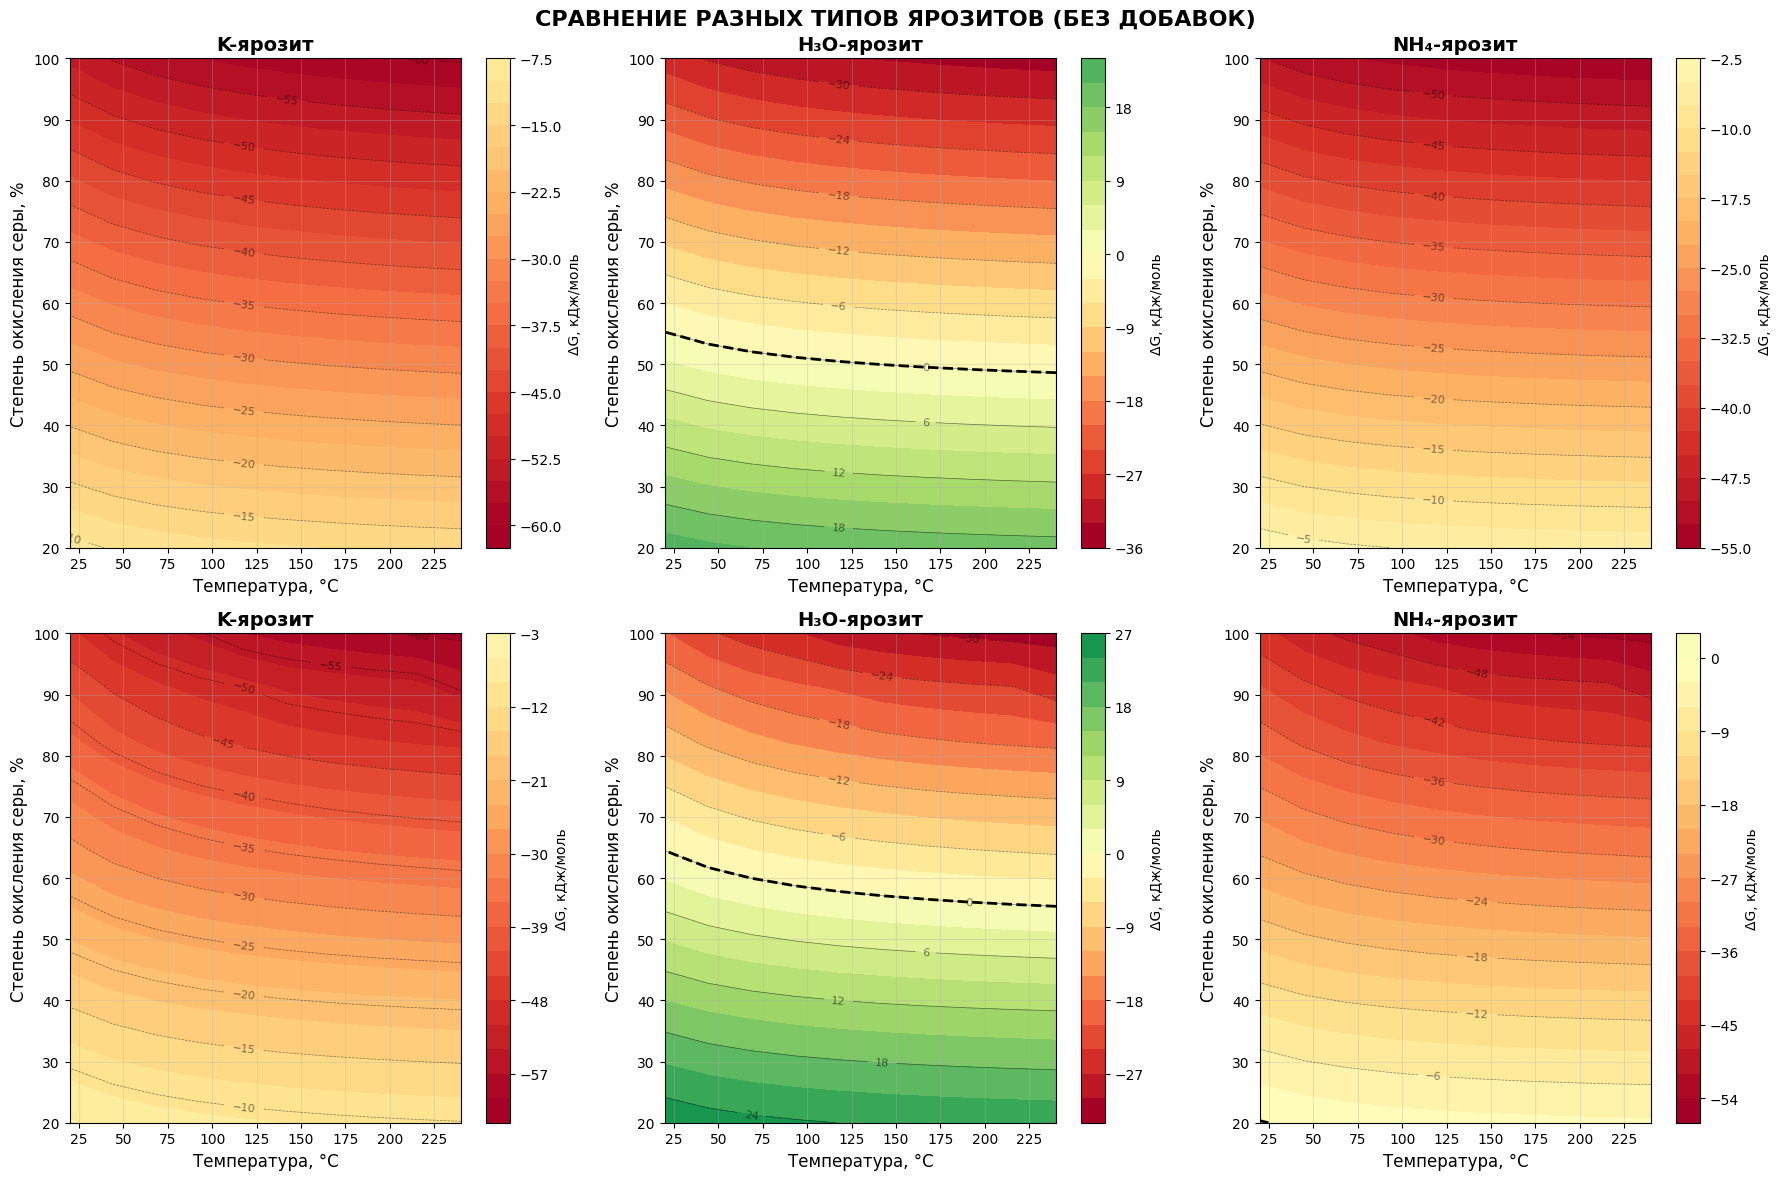

In [ ]:

fig_compare, axes_compare = plt.subplots(2, 3, figsize=(18, 12))
fig_compare.suptitle('СРАВНЕНИЕ РАЗНЫХ ТИПОВ ЯРОЗИТОВ (БЕЗ ДОБАВОК)', 
                     fontsize=16, fontweight='bold')


X, Y = np.meshgrid(temps_range - 273.15, S_Ox_range * 100)

scenario = 'no_add'

for idx, j_type in enumerate(jarosite_types):
    ax = axes_compare[0, idx]

    dG_data = np.zeros((len(S_Ox_range), len(temps_range)))
    for i in range(len(S_Ox_range)):
        for j in range(len(temps_range)):
            dG_data[i, j] = results[j_type][scenario]['report'][i, j]['dG_simple']

    max_abs = np.max(np.abs(dG_data))
    
    contour = ax.contourf(X, Y, dG_data.T, levels=20, cmap='RdYlGn', 
                          vmin=-max_abs, vmax=max_abs)
    
    plt.colorbar(contour, ax=ax, label='ΔG, кДж/моль')
    
    contour_lines = ax.contour(X, Y, dG_data.T, levels=10, colors='black', linewidths=0.5, alpha=0.5)
    ax.clabel(contour_lines, inline=True, fontsize=8)
    
    ax.contour(X, Y, dG_data.T, levels=[0], colors='black', linewidths=2, linestyles='--')
    
    ax.set_xlabel('Температура, °C', fontsize=12)
    
    ax.set_ylabel('Степень окисления серы, %', fontsize=12)
   
    
    ax.set_title(jarosite_params[j_type]['name'], fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)


for idx, j_type in enumerate(jarosite_types):
    ax = axes_compare[1, idx]
    
    dG_data = np.zeros((len(S_Ox_range), len(temps_range)))
    for i in range(len(S_Ox_range)):
        for j in range(len(temps_range)):
            dG_data[i, j] = results[j_type][scenario]['report'][i, j]['dG_full']
    
    max_abs = np.max(np.abs(dG_data))
    
    contour = ax.contourf(X, Y, dG_data.T, levels=20, cmap='RdYlGn', 
                          vmin=-max_abs, vmax=max_abs)
    plt.colorbar(contour, ax=ax, label='ΔG, кДж/моль')
    
    contour_lines = ax.contour(X, Y, dG_data.T, levels=10, colors='black', linewidths=0.5, alpha=0.5)
    ax.clabel(contour_lines, inline=True, fontsize=8)
    
    ax.contour(X, Y, dG_data.T, levels=[0], colors='black', linewidths=2, linestyles='--')
    
    ax.set_xlabel('Температура, °C', fontsize=12)
    
    ax.set_ylabel('Степень окисления серы, %', fontsize=12)
    
    ax.set_title(jarosite_params[j_type]['name'], fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

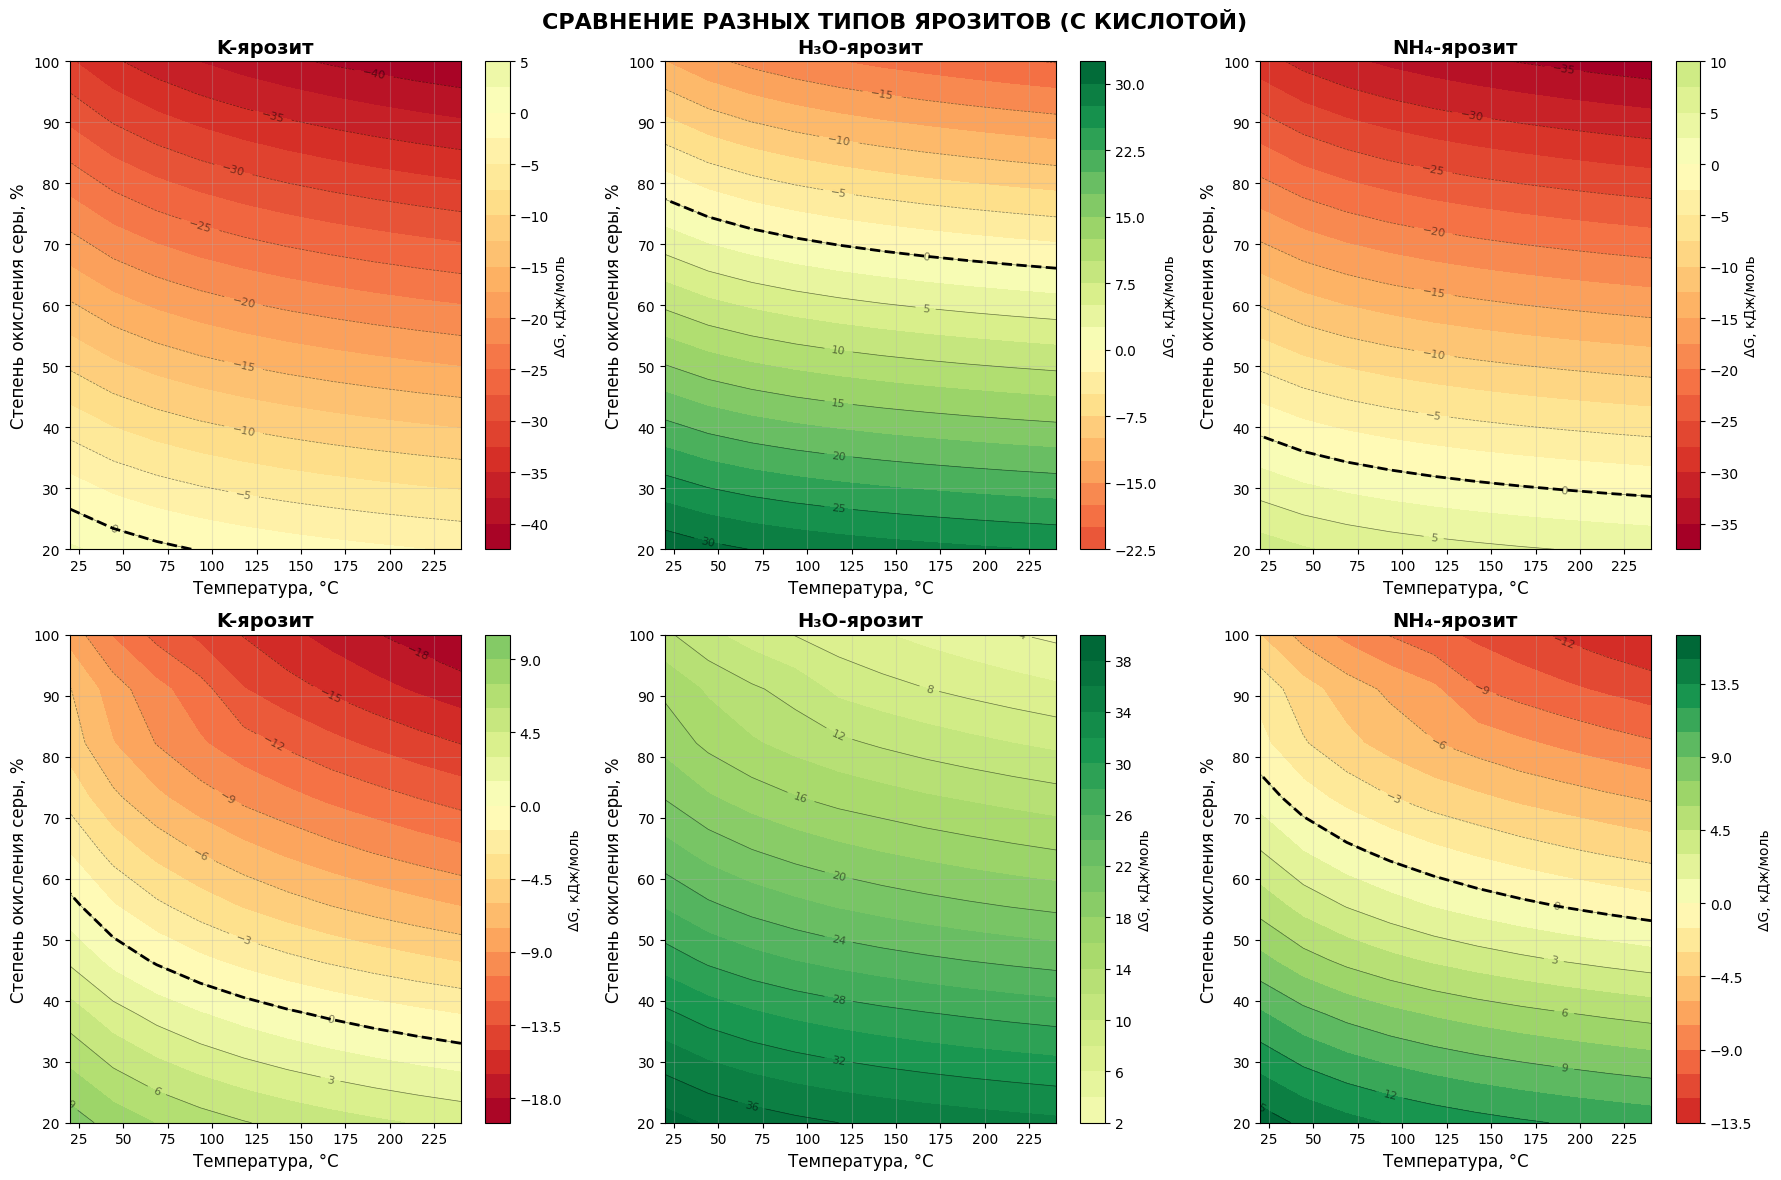

In [ ]:

fig_compare, axes_compare = plt.subplots(2, 3, figsize=(18, 12))
fig_compare.suptitle('СРАВНЕНИЕ РАЗНЫХ ТИПОВ ЯРОЗИТОВ (C КИСЛОТОЙ)', 
                     fontsize=16, fontweight='bold')


X, Y = np.meshgrid(temps_range - 273.15, S_Ox_range * 100)

scenario = 'with_acid'

for idx, j_type in enumerate(jarosite_types):
    ax = axes_compare[0, idx]
    
    dG_data = np.zeros((len(S_Ox_range), len(temps_range)))
    for i in range(len(S_Ox_range)):
        for j in range(len(temps_range)):
            dG_data[i, j] = results[j_type][scenario]['report'][i, j]['dG_simple']
    
    max_abs = np.max(np.abs(dG_data))
    
    contour = ax.contourf(X, Y, dG_data.T, levels=20, cmap='RdYlGn', 
                          vmin=-max_abs, vmax=max_abs)
    
    plt.colorbar(contour, ax=ax, label='ΔG, кДж/моль')
    
    contour_lines = ax.contour(X, Y, dG_data.T, levels=10, colors='black', linewidths=0.5, alpha=0.5)
    ax.clabel(contour_lines, inline=True, fontsize=8)
    
    ax.contour(X, Y, dG_data.T, levels=[0], colors='black', linewidths=2, linestyles='--')
    
    ax.set_xlabel('Температура, °C', fontsize=12)
    
    ax.set_ylabel('Степень окисления серы, %', fontsize=12)
   
    
    ax.set_title(jarosite_params[j_type]['name'], fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)


for idx, j_type in enumerate(jarosite_types):
    ax = axes_compare[1, idx]
    
    dG_data = np.zeros((len(S_Ox_range), len(temps_range)))
    for i in range(len(S_Ox_range)):
        for j in range(len(temps_range)):
            dG_data[i, j] = results[j_type][scenario]['report'][i, j]['dG_full']
    
    # Находим максимум для симметричной шкалы
    max_abs = np.max(np.abs(dG_data))
    
    contour = ax.contourf(X, Y, dG_data.T, levels=20, cmap='RdYlGn', 
                          vmin=-max_abs, vmax=max_abs)
    plt.colorbar(contour, ax=ax, label='ΔG, кДж/моль')
    
    contour_lines = ax.contour(X, Y, dG_data.T, levels=10, colors='black', linewidths=0.5, alpha=0.5)
    ax.clabel(contour_lines, inline=True, fontsize=8)
    
    ax.contour(X, Y, dG_data.T, levels=[0], colors='black', linewidths=2, linestyles='--')
    
    ax.set_xlabel('Температура, °C', fontsize=12)
    
    ax.set_ylabel('Степень окисления серы, %', fontsize=12)
    
    ax.set_title(jarosite_params[j_type]['name'], fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

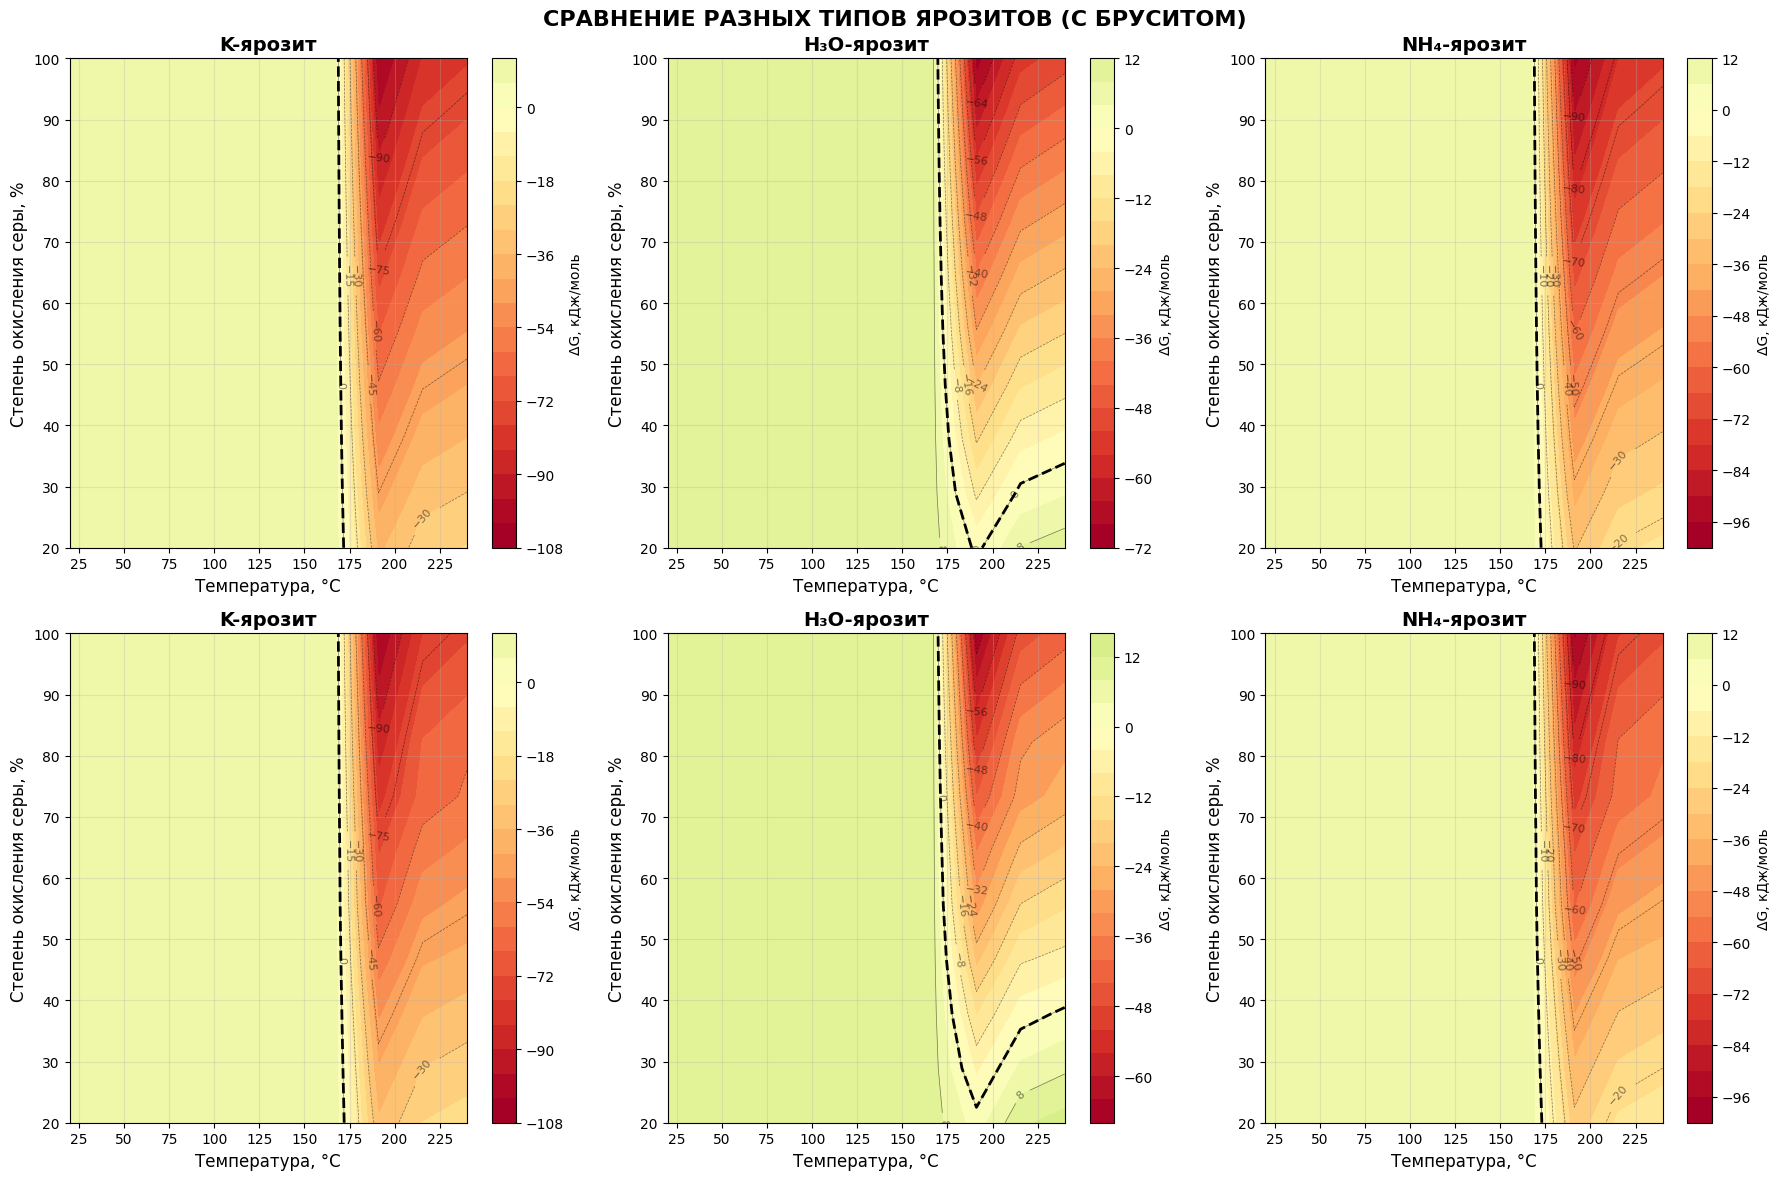

In [ ]:

fig_compare, axes_compare = plt.subplots(2, 3, figsize=(18, 12))
fig_compare.suptitle('СРАВНЕНИЕ РАЗНЫХ ТИПОВ ЯРОЗИТОВ (C БРУСИТОМ)', 
                     fontsize=16, fontweight='bold')


X, Y = np.meshgrid(temps_range - 273.15, S_Ox_range * 100)

scenario = 'with_bruc'

for idx, j_type in enumerate(jarosite_types):
    ax = axes_compare[0, idx]
    
    dG_data = np.zeros((len(S_Ox_range), len(temps_range)))
    for i in range(len(S_Ox_range)):
        for j in range(len(temps_range)):
            dG_data[i, j] = results[j_type][scenario]['report'][i, j]['dG_simple']
    
    max_abs = np.max(np.abs(dG_data))
    
    contour = ax.contourf(X, Y, dG_data.T, levels=20, cmap='RdYlGn', 
                          vmin=-max_abs, vmax=max_abs)
    
    plt.colorbar(contour, ax=ax, label='ΔG, кДж/моль')
    
    contour_lines = ax.contour(X, Y, dG_data.T, levels=10, colors='black', linewidths=0.5, alpha=0.5)
    ax.clabel(contour_lines, inline=True, fontsize=8)
    
    ax.contour(X, Y, dG_data.T, levels=[0], colors='black', linewidths=2, linestyles='--')
    
    ax.set_xlabel('Температура, °C', fontsize=12)
    
    ax.set_ylabel('Степень окисления серы, %', fontsize=12)
   
    
    ax.set_title(jarosite_params[j_type]['name'], fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)


for idx, j_type in enumerate(jarosite_types):
    ax = axes_compare[1, idx]
    
    dG_data = np.zeros((len(S_Ox_range), len(temps_range)))
    for i in range(len(S_Ox_range)):
        for j in range(len(temps_range)):
            dG_data[i, j] = results[j_type][scenario]['report'][i, j]['dG_full']
    
    # Находим максимум для симметричной шкалы
    max_abs = np.max(np.abs(dG_data))
    
    contour = ax.contourf(X, Y, dG_data.T, levels=20, cmap='RdYlGn', 
                          vmin=-max_abs, vmax=max_abs)
    plt.colorbar(contour, ax=ax, label='ΔG, кДж/моль')
    
    contour_lines = ax.contour(X, Y, dG_data.T, levels=10, colors='black', linewidths=0.5, alpha=0.5)
    ax.clabel(contour_lines, inline=True, fontsize=8)
    
    ax.contour(X, Y, dG_data.T, levels=[0], colors='black', linewidths=2, linestyles='--')
    
    ax.set_xlabel('Температура, °C', fontsize=12)
    
    ax.set_ylabel('Степень окисления серы, %', fontsize=12)
    
    ax.set_title(jarosite_params[j_type]['name'], fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

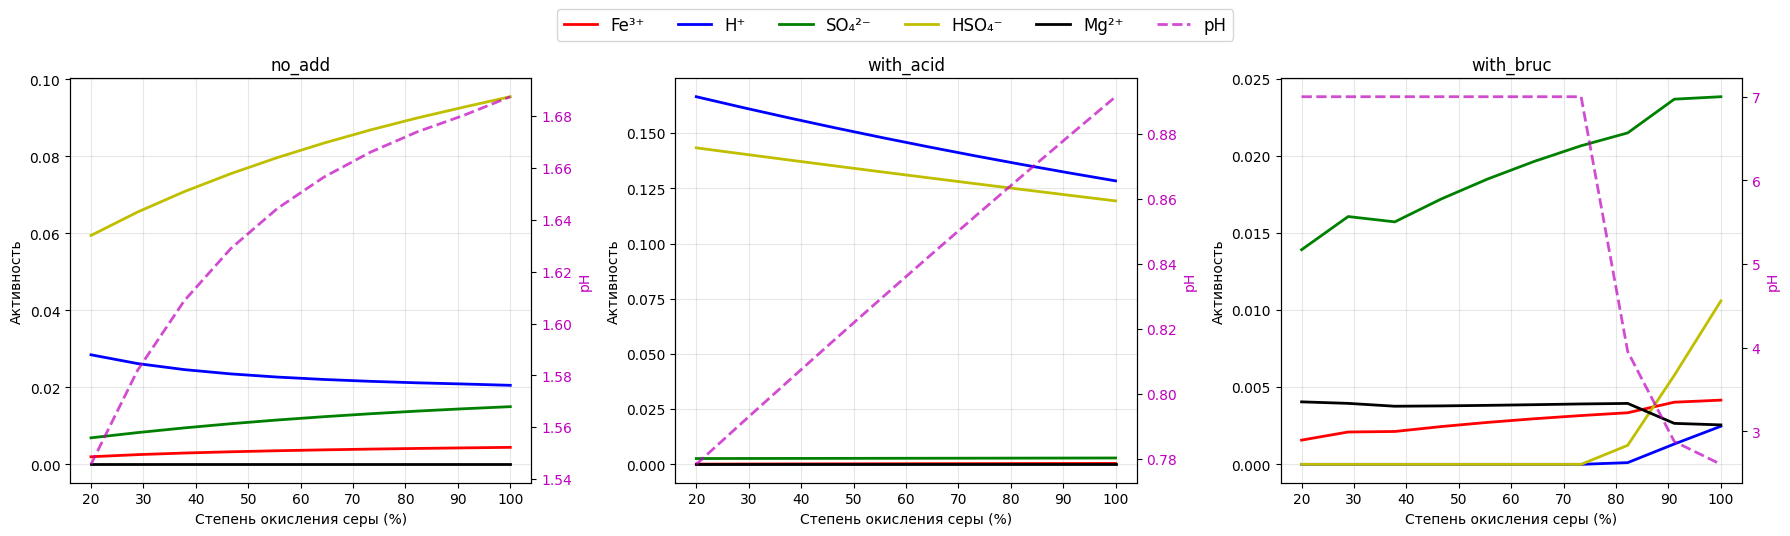

In [ ]:
fig_act, axes_act = plt.subplots(1, 3, figsize=(18, 5))

TEMP_IDX = 5 

for idx, scenario in enumerate(scenarios):
    ax = axes_act[idx]
    
    jar_data = results['K'][scenario]['report'] 
    
    line1 = ax.plot(S_Ox_grid[:, 0]*100, [r['a_Fe3'] for r in jar_data[:, TEMP_IDX]], 
                   'r-', linewidth=2, label='Fe³⁺')
    line2 = ax.plot(S_Ox_grid[:, 0]*100, [r['a_H'] for r in jar_data[:, TEMP_IDX]], 
                   'b-', linewidth=2, label='H⁺')
    line3 = ax.plot(S_Ox_grid[:, 0]*100, [r['a_SO4'] for r in jar_data[:, TEMP_IDX]], 
                   'g-', linewidth=2, label='SO₄²⁻')
    line4 = ax.plot(S_Ox_grid[:, 0]*100, [r['a_HSO4'] for r in jar_data[:, TEMP_IDX]], 
                   'y-', linewidth=2, label='HSO₄⁻')
    line5 = ax.plot(S_Ox_grid[:, 0]*100, [r['a_Mg2'] for r in jar_data[:, TEMP_IDX]], 
                   'black', linewidth=2, label='Mg²⁺')
    
    ax.set_xlabel('Степень окисления серы (%)')
    ax.set_ylabel('Активность')
    ax.grid(True, alpha=0.3)
    ax.set_title(f'{scenario}')
    
    ax2 = ax.twinx()
    line6 = ax2.plot(S_Ox_grid[:, 0]*100, [r['pH'] for r in jar_data[:, TEMP_IDX]], 
                    'm--', linewidth=2, label='pH', alpha=0.7)
    ax2.set_ylabel('pH', color='m')
    ax2.tick_params(axis='y', labelcolor='m')
    
    if idx == 0:
        lines = [line1[0], line2[0], line3[0], line4[0], line5[0], line6[0]]

labels = ['Fe³⁺', 'H⁺', 'SO₄²⁻', 'HSO₄⁻', 'Mg²⁺', 'pH']
fig_act.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=6, fontsize=12)
plt.tight_layout()
plt.show()

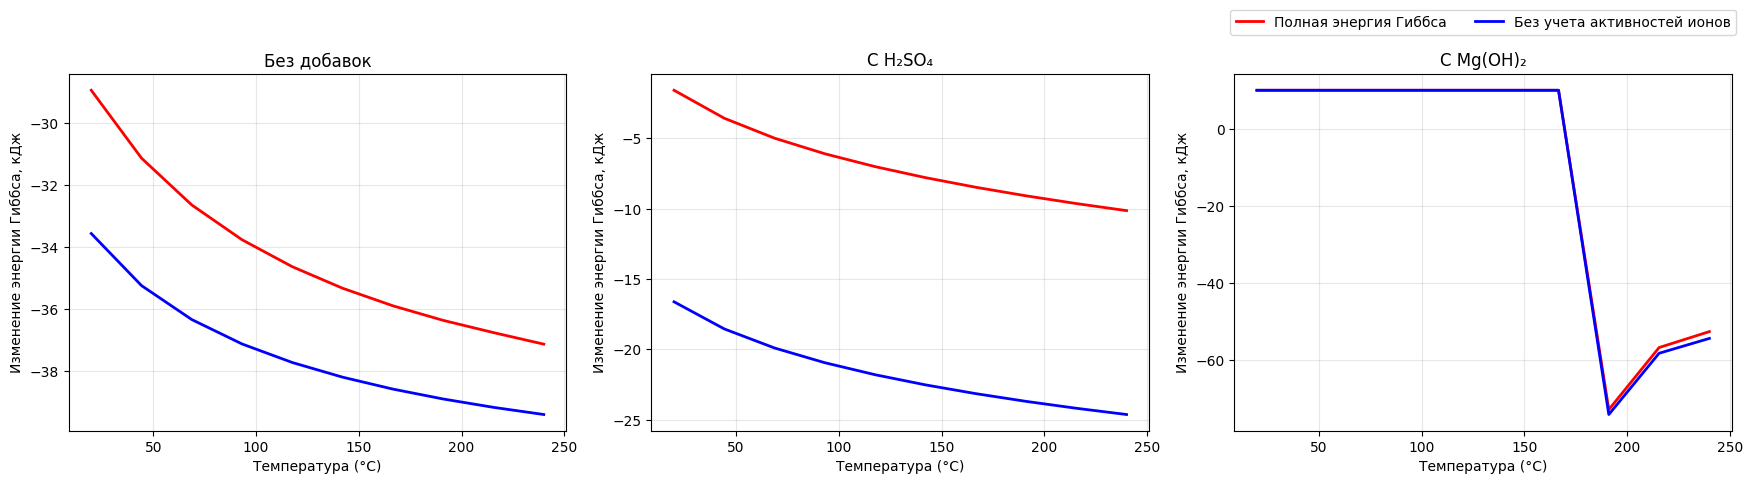

In [ ]:
fig_act, axes_act = plt.subplots(1, 3, figsize=(18, 5))

S_Ox_IDX = 3 

for i, scenario in enumerate(scenarios):
    
    ax = axes_act[i]
    
    jar_data = results['K'][scenario]['report'] 
    
    temp_c = T_grid[0, :] - 273.15
    
    line1 = ax.plot(temp_c, [r['dG_full'] for r in jar_data[:, TEMP_IDX]], 
                   'r-', linewidth=2, label='Энергия Гиббса (полная)')
    line2 = ax.plot(temp_c, [r['dG_simple'] for r in jar_data[:, TEMP_IDX]], 
                   'b-', linewidth=2, label='Энергия Гиббса (без учета активностей)')
   
    ax.set_xlabel('Температура (°C)')
    ax.set_ylabel('Изменение энергии Гиббса, кДж')
    ax.grid(True, alpha=0.3)
    
    ax2.tick_params(axis='y', labelcolor='m')
    
    scenario_names = {'no_add': 'Без добавок', 
                      'with_acid': 'С H₂SO₄', 
                      'with_bruc': 'С Mg(OH)₂'}
    ax.set_title(f'{scenario_names.get(scenario, scenario)}')

ax.legend(handles=[line1[0], line2[0]],
              labels=['Полная энергия Гиббса', 'Без учета активностей ионов'],
              loc='upper center', bbox_to_anchor=(0.5, 1.2),
                ncol=5)

plt.tight_layout()
plt.show()

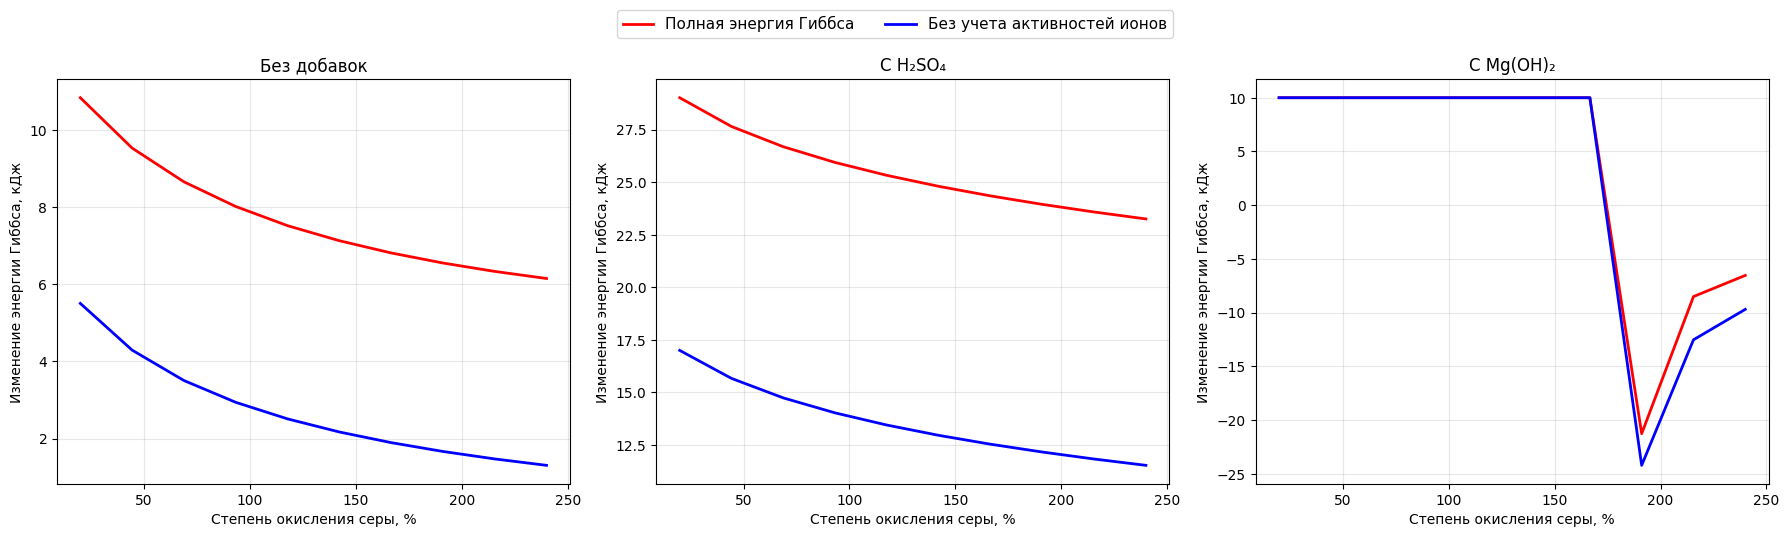

In [ ]:
fig_act, axes_act = plt.subplots(1, 3, figsize=(18, 5))

TEMP_IDX = 3  

for i, scenario in enumerate(scenarios):
    ax = axes_act[i]
    jar_data = results['H3O'][scenario]['report'] 
    
    
    temp_c = T_grid[0, :] - 273.15
    
    line1 = ax.plot(temp_c, [r['dG_full'] for r in jar_data[:, TEMP_IDX]], 
                   'r-', linewidth=2, label='Энергия Гиббса (полная)')
    line2 = ax.plot(temp_c, [r['dG_simple'] for r in jar_data[:, TEMP_IDX]], 
                   'b-', linewidth=2, label='Энергия Гиббса (без учета активностей)')
   
    ax.set_xlabel('Степень окисления серы, %')
    ax.set_ylabel('Изменение энергии Гиббса, кДж')
    ax.grid(True, alpha=0.3)
    
    ax2.tick_params(axis='y', labelcolor='m')
    
    scenario_names = {'no_add': 'Без добавок', 
                      'with_acid': 'С H₂SO₄', 
                      'with_bruc': 'С Mg(OH)₂'}
    ax.set_title(f'{scenario_names.get(scenario, scenario)}')

fig_act.legend(handles=[line1[0], line2[0]],
              labels=['Полная энергия Гиббса', 'Без учета активностей ионов'],
              loc='upper center', bbox_to_anchor=(0.5, 1.08),
              ncol=4, fontsize=11)

plt.tight_layout()
plt.show()

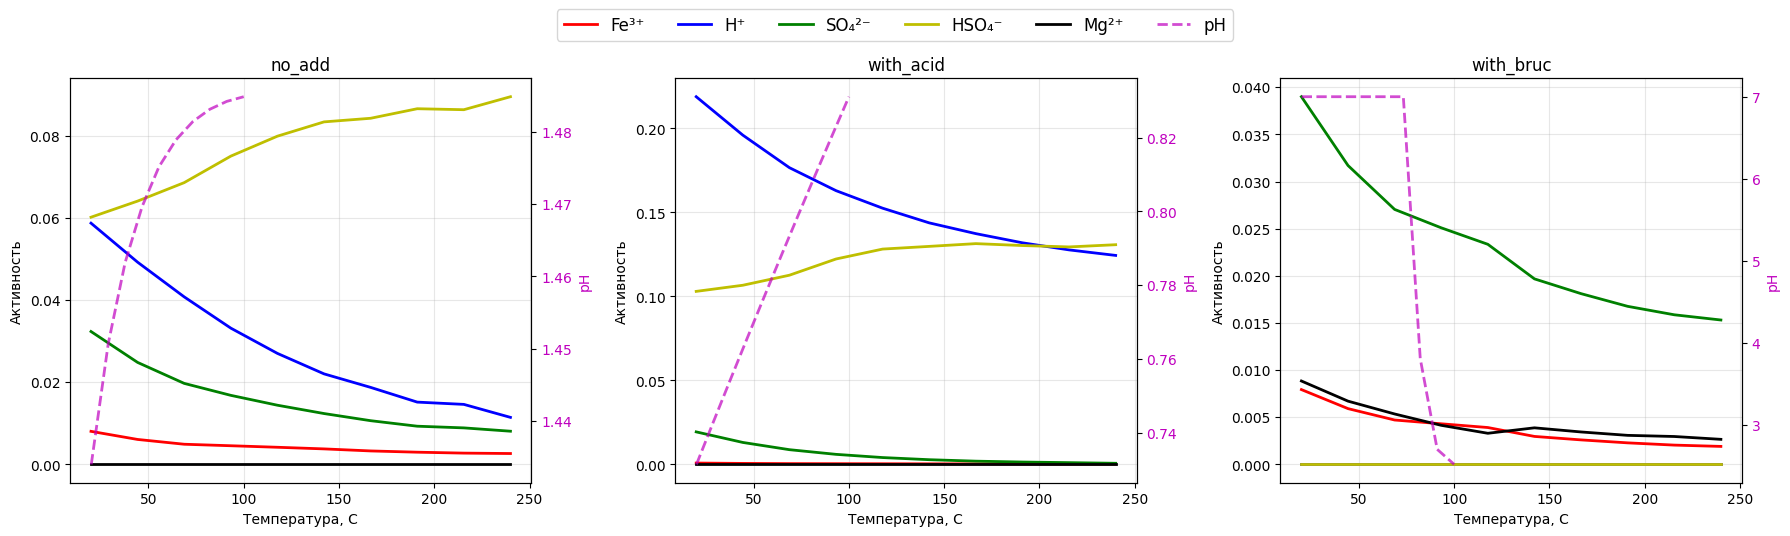

In [ ]:
fig_act, axes_act = plt.subplots(1, 3, figsize=(18, 5))

S_Ox_IDX = 5 

for idx, scenario in enumerate(scenarios):
    ax = axes_act[idx]
    
    jar_data = results['K'][scenario]['report'] 
    
    line1 = ax.plot(temp_c, [r['a_Fe3'] for r in jar_data[S_Ox_IDX, :]], 
                   'r-', linewidth=2, label='Fe³⁺')
    line2 = ax.plot(temp_c, [r['a_H'] for r in jar_data[S_Ox_IDX, :]], 
                   'b-', linewidth=2, label='H⁺')
    line3 = ax.plot(temp_c, [r['a_SO4'] for r in jar_data[S_Ox_IDX, :]], 
                   'g-', linewidth=2, label='SO₄²⁻')
    line4 = ax.plot(temp_c, [r['a_HSO4'] for r in jar_data[S_Ox_IDX, :]], 
                   'y-', linewidth=2, label='HSO₄⁻')
    line5 = ax.plot(temp_c, [r['a_Mg2'] for r in jar_data[S_Ox_IDX, :]], 
                   'black', linewidth=2, label='Mg²⁺')
    
    ax.set_xlabel('Температура, С')
    ax.set_ylabel('Активность')
    ax.grid(True, alpha=0.3)
    ax.set_title(f'{scenario}')
    
    ax2 = ax.twinx()
    line6 = ax2.plot(S_Ox_grid[:, 0]*100, [r['pH'] for r in jar_data[:, TEMP_IDX]], 
                    'm--', linewidth=2, label='pH', alpha=0.7)
    ax2.set_ylabel('pH', color='m')
    ax2.tick_params(axis='y', labelcolor='m')
    
    if idx == 0:
        lines = [line1[0], line2[0], line3[0], line4[0], line5[0], line6[0]]

labels = ['Fe³⁺', 'H⁺', 'SO₄²⁻', 'HSO₄⁻', 'Mg²⁺', 'pH']
fig_act.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=6, fontsize=12)
plt.tight_layout()
plt.show()

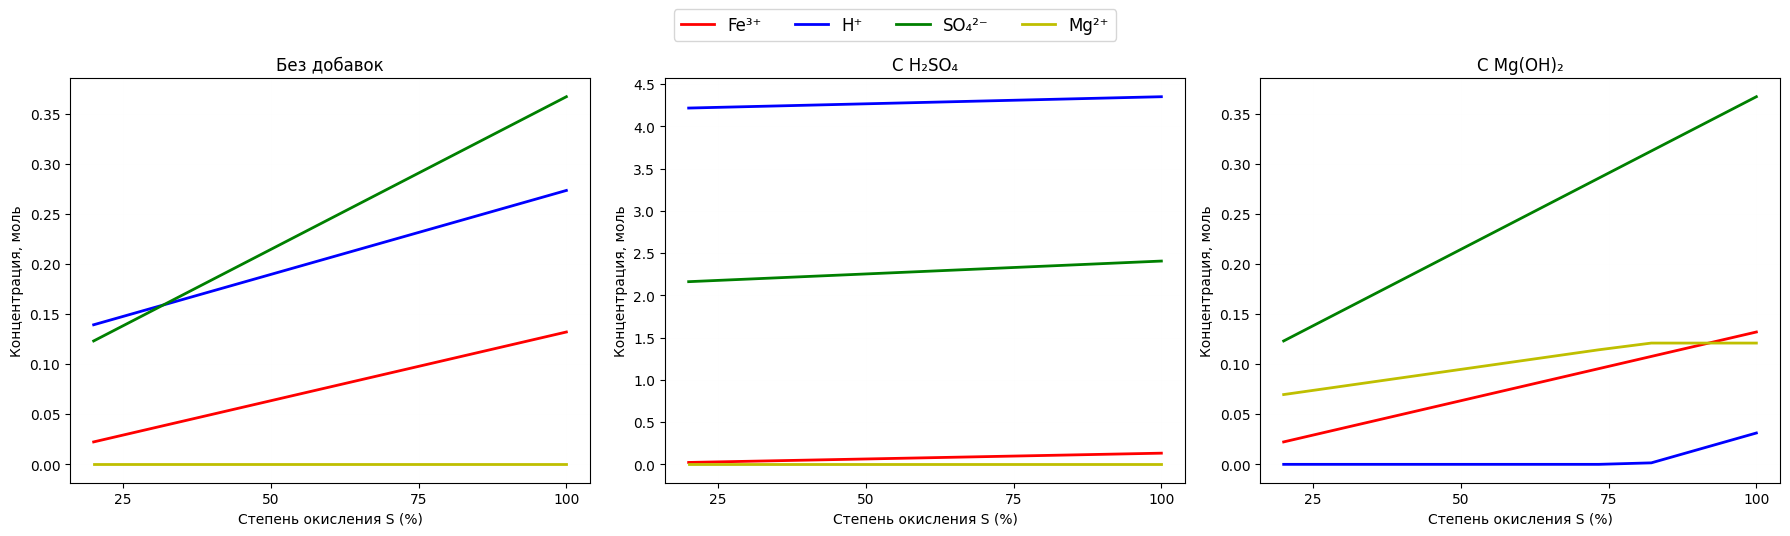

In [ ]:
fig_conc, axes_conc = plt.subplots(1, 3, figsize=(18, 5))

TEMP_IDX = 5  

for i, scenario in enumerate(scenarios):
    ax = axes_conc[i]
    jar_data = results['K'][scenario]['report'] 
    
    line1 = ax.plot(S_Ox_grid[:, 0]*100, [r['C_Fe3'] for r in jar_data[:, TEMP_IDX]], 
                   'r-', linewidth=2, label='Fe³⁺')

    line2 = ax.plot(S_Ox_grid[:, 0]*100, [r['C_H'] for r in jar_data[:, TEMP_IDX]], 
                   'b-', linewidth=2, label='H⁺')
    line3 = ax.plot(S_Ox_grid[:, 0]*100, [r['C_SO4'] for r in jar_data[:, TEMP_IDX]], 
                   'g-', linewidth=2, label='SO₄²⁻')
    line4 = ax.plot(S_Ox_grid[:, 0]*100, [r['C_Mg2'] for r in jar_data[:, TEMP_IDX]], 
                   'y-', linewidth=2, label='Mg²⁺')
    
    ax.set_xlabel('Степень окисления S (%)')
    ax.set_ylabel('Концентрация, моль')
    ax.grid(True, alpha=0.01)
    ax.locator_params(axis='x', nbins=4) 
    ax.locator_params(axis='y', nbins=10) 
    scenario_names = {'no_add': 'Без добавок', 
                      'with_acid': 'С H₂SO₄', 
                      'with_bruc': 'С Mg(OH)₂'}
    ax.set_title(f'{scenario_names.get(scenario, scenario)}')


fig_conc.legend(handles=[line1[0], line2[0], line3[0],line4[0]], 
              labels=['Fe³⁺', 'H⁺', 'SO₄²⁻','Mg²⁺'],
              loc='upper center', bbox_to_anchor=(0.5, 1.08),
              ncol=4, fontsize=12)
    

plt.tight_layout()
plt.show()

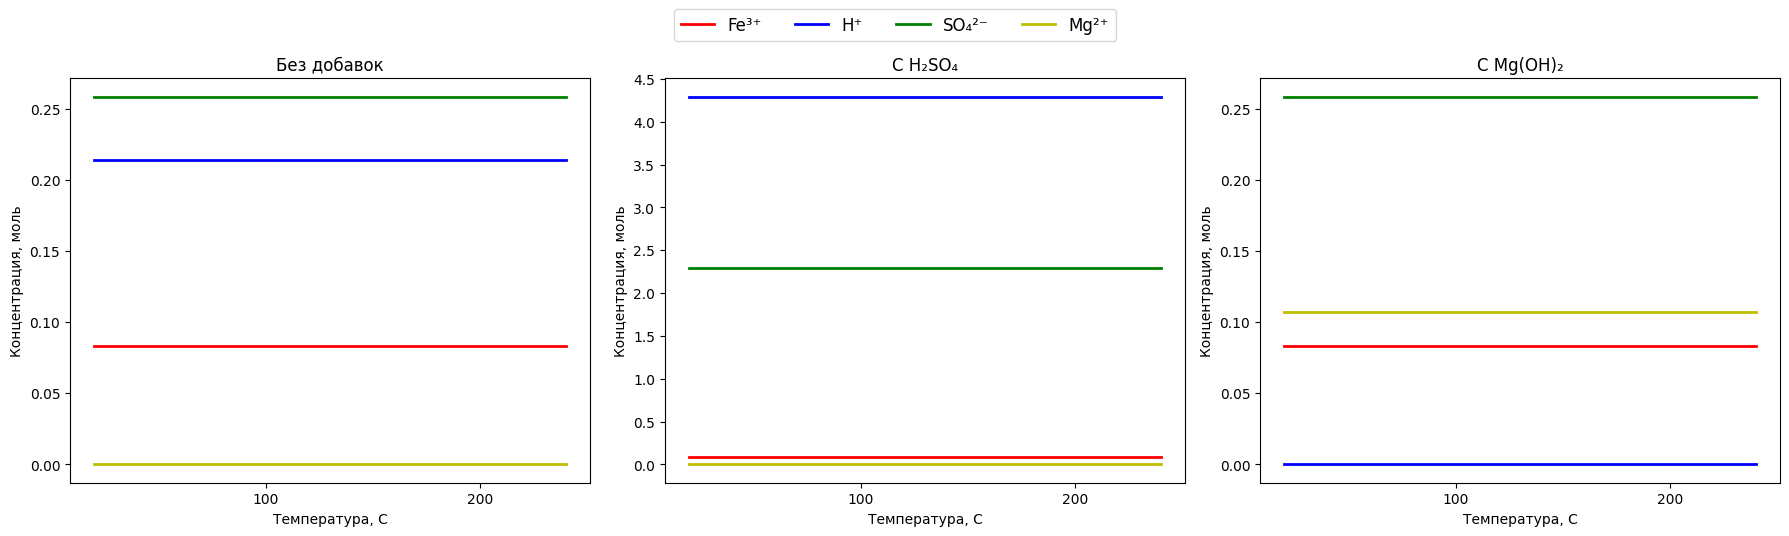

In [ ]:
fig_conc, axes_conc = plt.subplots(1, 3, figsize=(18, 5))

S_Ox_IDX = 5  

for i, scenario in enumerate(scenarios):
    ax = axes_conc[i]
    jar_data = results['K'][scenario]['report'] 
    
    line1 = ax.plot(temp_c, [r['C_Fe3'] for r in jar_data[S_Ox_IDX, :]], 
                   'r-', linewidth=2, label='Fe³⁺')

    line2 = ax.plot(temp_c, [r['C_H'] for r in jar_data[S_Ox_IDX, :]], 
                   'b-', linewidth=2, label='H⁺')
    line3 = ax.plot(temp_c, [r['C_SO4'] for r in jar_data[S_Ox_IDX, :]], 
                   'g-', linewidth=2, label='SO₄²⁻')
    line4 = ax.plot(temp_c, [r['C_Mg2'] for r in jar_data[S_Ox_IDX, :]], 
                   'y-', linewidth=2, label='Mg²⁺')
    
    ax.set_xlabel('Температура, С')
    ax.set_ylabel('Концентрация, моль')
    ax.grid(True, alpha=0.01)
    ax.locator_params(axis='x', nbins=4) 
    ax.locator_params(axis='y', nbins=10) 
    scenario_names = {'no_add': 'Без добавок', 
                      'with_acid': 'С H₂SO₄', 
                      'with_bruc': 'С Mg(OH)₂'}
    ax.set_title(f'{scenario_names.get(scenario, scenario)}')


fig_conc.legend(handles=[line1[0], line2[0], line3[0],line4[0]], 
              labels=['Fe³⁺', 'H⁺', 'SO₄²⁻','Mg²⁺'],
              loc='upper center', bbox_to_anchor=(0.5, 1.08),
              ncol=4, fontsize=12)
    

plt.tight_layout()
plt.show()

In [ ]:
import nbformat
from nbconvert import HTMLExporter
import os
import webbrowser
from datetime import datetime

with open('code_notebook.ipynb', 'r', encoding='utf-8') as f:
    notebook = nbformat.read(f, as_version=4)

# Конвертируем в HTML
html_exporter = HTMLExporter()
html_exporter.exclude_input = False 
body, resources = html_exporter.from_notebook_node(notebook)

# Сохраняем с уникальным именем
filename = f"jarosite_report_{datetime.now().strftime('%Y%m%d_%H%M%S')}.html"
with open(filename, 'w', encoding='utf-8') as f:
    f.write(body)

print(f"✅ Отчет сохранен: {os.path.abspath(filename)}")
print(f"📊 Размер файла: {os.path.getsize(filename)} байт")
webbrowser.open(filename)

✅ Отчет сохранен: f:\Термодинамика процесса гидролиза\Python\jarosite_report_20260310_143831.html
📊 Размер файла: 3989486 байт


True